# Songwriter Style Analysis Project

## Analyzed Songwriters (12 Total)
1. **Max Martin** - Pop hits, catchy hooks
2. **Sia Furler** - Powerful vocals, emotional lyrics
3. **Ryan Tedder** - Anthemic choruses, piano-driven
4. **Julia Michaels** - Personal, confessional lyrics
5. **The-Dream** - R&B melodies, romantic themes
6. **Jack Antonoff** - 80s-inspired production, indie-pop
7. **Shellback** - Pop production, Max Martin collaborator
8. **Benny Blanco** - Pop and hip-hop fusion
9. **Stargate** - R&B and pop production
10. **Dr. Luke** - Pop hits, electronic production
11. **Greg Kurstin** - Alternative pop, diverse production
12. **Diplo** - Electronic, dancehall, pop fusion



In [127]:
# Cell 1: Import Essential Libraries
import lyricsgenius as lg
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

print("Essential libraries imported successfully!")
print("  - lyricsgenius (Genius API)")
print("  - pandas (Data manipulation)")
print("  - numpy (Numerical operations)")


Essential libraries imported successfully!
  - lyricsgenius (Genius API)
  - pandas (Data manipulation)
  - numpy (Numerical operations)


In [128]:
# Cell 2: Configure Genius API
from config import GENIUS_TOKEN, LASTFM_API_KEY, LASTFM_API_SECRET

# Initialize the Genius API client
genius = lg.Genius(
    GENIUS_TOKEN, 
    skip_non_songs=True,           # Skip non-song results
    remove_section_headers=True,   # Remove [Chorus], [Verse] etc.
    verbose=False                  # Don't print status messages
)

print("Genius API initialized successfully!")

Genius API initialized successfully!


In [ ]:
# Cell 3: Test API connection
print("Testing Genius API connection...\n")
print("="*60)

try:
    # Search for a test song
    test_song = genius.search_song("Blinding Lights", "The Weeknd")
    
    if test_song:
        print("[OK] API connection successful!\n")
        print(f"Song Title:    {test_song.title}")
        print(f"Artist:        {test_song.artist}")
        
        # Handle release date/year
        if hasattr(test_song, 'release_date'):
            print(f"Release Date:  {test_song.release_date}")
        elif hasattr(test_song, 'year'):
            print(f"Release Year:  {test_song.year}")
            
        # Handle URL
        if hasattr(test_song, 'url'):
            print(f"URL:          {test_song.url}")
            
        # Get additional metadata from the song's JSON data
        if hasattr(test_song, '_body'):
            metadata = test_song._body
            
            # Get writers
            if 'writer_artists' in metadata:
                writers = [writer['name'] for writer in metadata['writer_artists']]
                print(f"Writers:       {', '.join(writers)}")
                
            # Get producer
            if 'producer_artists' in metadata:
                producers = [prod['name'] for prod in metadata['producer_artists']]
                print(f"Producers:     {', '.join(producers)}")
        
        if hasattr(test_song, 'lyrics'):
            print(f"\nLyrics Length: {len(test_song.lyrics)} characters")
            print(f"\nLyrics Preview:")
            print("-" * 60)
            print(test_song.lyrics[:200] + "...")
    else:
        print("Song not found")
        
except Exception as e:
    print(f"Error: {str(e)}")
    print("\nPlease check your API token and internet connection!")

print("\n" + "="*60)
print("STEP 1 COMPLETE - API test finished!")

Testing Genius API connection...

✓ API Connection Successful!

Song Title:    Blinding Lights
Artist:        The Weeknd
URL:          https://genius.com/The-weeknd-blinding-lights-lyrics
Writers:       The Weeknd, Oscar Holter, Max Martin, Belly, DaHeala
Producers:     The Weeknd, Max Martin, Oscar Holter

Lyrics Length: 1239 characters

Lyrics Preview:
------------------------------------------------------------
Yeah

I've been tryna call
I've been on my own for long enough
Maybe you can show me how to love, maybe
I'm goin' through withdrawals
You don't even have to do too much
You can turn me on with just a ...

STEP 1 COMPLETE - API test finished!
✓ API Connection Successful!

Song Title:    Blinding Lights
Artist:        The Weeknd
URL:          https://genius.com/The-weeknd-blinding-lights-lyrics
Writers:       The Weeknd, Oscar Holter, Max Martin, Belly, DaHeala
Producers:     The Weeknd, Max Martin, Oscar Holter

Lyrics Length: 1239 characters

Lyrics Preview:
-----------------

In [93]:
# Cell 5: Last.fm API Configuration
import pylast
import requests
import json

# Initialize Last.fm network
lastfm_network = pylast.LastFMNetwork(
    api_key=LASTFM_API_KEY,
    api_secret=LASTFM_API_SECRET
)

print("Last.fm API configured!")

Last.fm API configured!


In [94]:
# Cell 6: Test Last.fm API Connection
print("Testing Last.fm API connection...\n")
print("="*60)

try:
    # Test 1: Get track info
    track = lastfm_network.get_track("The Weeknd", "Blinding Lights")
    
    print("Last.fm Connection Successful!\n")
    print(f"Track:         {track.get_name()}")
    print(f"Artist:        {track.get_artist()}")
    print(f"Playcount:     {track.get_playcount():,}")
    print(f"Listeners:     {track.get_listener_count():,}")
    
    # Get tags/genres
    tags = track.get_top_tags(limit=5)
    print(f"\nTop Tags/Genres:")
    for tag in tags:
        print(f"  - {tag.item.get_name()}: {tag.weight}")
    
    # Test 2: Get artist info
    print("\n" + "-"*60)
    artist = lastfm_network.get_artist("The Weeknd")
    print(f"\nArtist:        {artist.get_name()}")
    print(f"Playcount:     {artist.get_playcount():,}")
    print(f"Listeners:     {artist.get_listener_count():,}")
    
    # Get similar artists
    similar = artist.get_similar(limit=3)
    print(f"\nSimilar Artists:")
    for similar_artist in similar:
        print(f"  - {similar_artist.item.get_name()}")
    
except Exception as e:
    print(f"Error: {e}")
    print("\nCheck that your API key is correct!")

print("\n" + "="*60)
print("STEP 2 COMPLETE - Last.fm API is working!")

Testing Last.fm API connection...

Last.fm Connection Successful!

Track:         Blinding Lights
Artist:        The Weeknd
Playcount:     36,183,473
Listeners:     2,196,858
Playcount:     36,183,473
Listeners:     2,196,858

Top Tags/Genres:
  - synthwave: 100
  - synthpop: 94
  - pop: 51
  - 2019: 30
  - 2010s: 12

------------------------------------------------------------

Artist:        The Weeknd
Playcount:     1,018,830,297

Top Tags/Genres:
  - synthwave: 100
  - synthpop: 94
  - pop: 51
  - 2019: 30
  - 2010s: 12

------------------------------------------------------------

Artist:        The Weeknd
Playcount:     1,018,830,297
Listeners:     5,016,058
Listeners:     5,016,058

Similar Artists:
  - Tory Lanez
  - Drake
  - PARTYNEXTDOOR

STEP 2 COMPLETE - Last.fm API is working!

Similar Artists:
  - Tory Lanez
  - Drake
  - PARTYNEXTDOOR

STEP 2 COMPLETE - Last.fm API is working!


In [99]:
# Cell 7: Target Songwriters and Producers for Analysis

# List of prolific songwriters/producers known for distinctive styles
target_writers = {
    # Pop Songwriters
    'Max Martin': {
        'known_for': 'Pop hits, catchy hooks',
        'notable_artists': ['Taylor Swift', 'The Weeknd', 'Ariana Grande', 'Katy Perry']
    },
    'Sia Furler': {
        'known_for': 'Powerful vocals, emotional lyrics',
        'notable_artists': ['Rihanna', 'Beyoncé', 'David Guetta', 'Sia']
    },
    'Ryan Tedder': {
        'known_for': 'Anthemic choruses, piano-driven',
        'notable_artists': ['Beyoncé', 'Adele', 'Taylor Swift', 'OneRepublic']
    },
    'Julia Michaels': {
        'known_for': 'Personal, confessional lyrics',
        'notable_artists': ['Selena Gomez', 'Justin Bieber', 'Demi Lovato']
    },
    
    # Hip-Hop/R&B Producers & Writers
    'The-Dream': {
        'known_for': 'R&B melodies, romantic themes',
        'notable_artists': ['Beyoncé', 'Rihanna', 'Mariah Carey']
    },
    
    # Alternative/Indie
    'Jack Antonoff': {
        'known_for': '80s-inspired production, indie-pop',
        'notable_artists': ['Taylor Swift', 'Lorde', 'Lana Del Rey']
    },
    
    # Additional Songwriters
    'Shellback': {
        'known_for': 'Pop production, Max Martin collaborator',
        'notable_artists': ['Taylor Swift', 'Pink', 'Maroon 5', 'Ariana Grande']
    },
    'Benny Blanco': {
        'known_for': 'Pop and hip-hop fusion',
        'notable_artists': ['Ed Sheeran', 'Justin Bieber', 'Halsey', 'Maroon 5']
    },
    'Stargate': {
        'known_for': 'R&B and pop production',
        'notable_artists': ['Rihanna', 'Beyoncé', 'Ne-Yo', 'Katy Perry']
    },
    'Dr. Luke': {
        'known_for': 'Pop hits, electronic production',
        'notable_artists': ['Katy Perry', 'Kesha', 'Doja Cat', 'Kim Petras']
    },
    'Greg Kurstin': {
        'known_for': 'Alternative pop, diverse production',
        'notable_artists': ['Adele', 'Beck', 'Foo Fighters', 'Sia']
    },
    'Diplo': {
        'known_for': 'Electronic, dancehall, pop fusion',
        'notable_artists': ['Major Lazer', 'Justin Bieber', 'M.I.A.', 'Beyoncé']
    }
}

print("Target Songwriters/Producers Selected:")
print("="*60)
for writer, info in target_writers.items():
    print(f"\n{writer}")
    print(f"  Style: {info['known_for']}")
    print(f"  Artists: {', '.join(info['notable_artists'][:3])}")

print("\n" + "="*60)
print(f"Total: {len(target_writers)} songwriters/producers")


Target Songwriters/Producers Selected:

Max Martin
  Style: Pop hits, catchy hooks
  Artists: Taylor Swift, The Weeknd, Ariana Grande

Sia Furler
  Style: Powerful vocals, emotional lyrics
  Artists: Rihanna, Beyoncé, David Guetta

Ryan Tedder
  Style: Anthemic choruses, piano-driven
  Artists: Beyoncé, Adele, Taylor Swift

Julia Michaels
  Style: Personal, confessional lyrics
  Artists: Selena Gomez, Justin Bieber, Demi Lovato

The-Dream
  Style: R&B melodies, romantic themes
  Artists: Beyoncé, Rihanna, Mariah Carey

Jack Antonoff
  Style: 80s-inspired production, indie-pop
  Artists: Taylor Swift, Lorde, Lana Del Rey

Shellback
  Style: Pop production, Max Martin collaborator
  Artists: Taylor Swift, Pink, Maroon 5

Benny Blanco
  Style: Pop and hip-hop fusion
  Artists: Ed Sheeran, Justin Bieber, Halsey

Stargate
  Style: R&B and pop production
  Artists: Rihanna, Beyoncé, Ne-Yo

Dr. Luke
  Style: Pop hits, electronic production
  Artists: Katy Perry, Kesha, Doja Cat

Greg Kurstin


In [100]:
# Cell 8: Test collecting songs with writer/producer credits
import time

print("Testing data collection with writer/producer extraction")
print("="*60)

test_songs = [
    ("Blinding Lights", "The Weeknd"),
    ("Umbrella", "Rihanna"),
    ("Counting Stars", "OneRepublic")
]

collected_data = []

for song_title, artist_name in test_songs:
    print(f"\nSearching: {song_title} by {artist_name}")
    
    try:
        song = genius.search_song(song_title, artist_name)
        
        if song and hasattr(song, '_body'):
            metadata = song._body
            
            # Extract writers
            writers = []
            if 'writer_artists' in metadata:
                writers = [w['name'] for w in metadata['writer_artists']]
            
            # Extract producers
            producers = []
            if 'producer_artists' in metadata:
                producers = [p['name'] for p in metadata['producer_artists']]
            
            # Get Last.fm data
            try:
                lastfm_track = lastfm_network.get_track(artist_name, song_title)
                playcount = lastfm_track.get_playcount()
            except:
                playcount = 0
            
            song_data = {
                'title': song.title,
                'artist': song.artist,
                'writers': ', '.join(writers) if writers else 'Unknown',
                'producers': ', '.join(producers) if producers else 'Unknown',
                'playcount': playcount,
                'lyrics_length': len(song.lyrics) if song.lyrics else 0
            }
            
            collected_data.append(song_data)
            
            print(f"  [OK] Writers: {song_data['writers']}")
            print(f"  [OK] Producers: {song_data['producers']}")
            print(f"  [OK] Playcount: {playcount:,}")
            
        time.sleep(1)  # Be nice to the APIs
        
    except Exception as e:
        print(f"  [ERROR] {e}")

print("\n" + "="*60)
print(f"Collected data for {len(collected_data)} songs")

# Convert to DataFrame for preview
df_preview = pd.DataFrame(collected_data)
print("\nPreview of collected data:")
print(df_preview)


Testing data collection with writer/producer extraction

Searching: Blinding Lights by The Weeknd
  [OK] Writers: The Weeknd, Oscar Holter, Max Martin, Belly, DaHeala
  [OK] Producers: The Weeknd, Max Martin, Oscar Holter
  [OK] Playcount: 36,183,473
  [OK] Writers: The Weeknd, Oscar Holter, Max Martin, Belly, DaHeala
  [OK] Producers: The Weeknd, Max Martin, Oscar Holter
  [OK] Playcount: 36,183,473

Searching: Umbrella by Rihanna

Searching: Umbrella by Rihanna
  [OK] Writers: Kuk Harrell, Tricky Stewart, JAY-Z, The-Dream
  [OK] Producers: Kuk Harrell, Tricky Stewart
  [OK] Playcount: 15,662,065
  [OK] Writers: Kuk Harrell, Tricky Stewart, JAY-Z, The-Dream
  [OK] Producers: Kuk Harrell, Tricky Stewart
  [OK] Playcount: 15,662,065

Searching: Counting Stars by OneRepublic

Searching: Counting Stars by OneRepublic
  [OK] Writers: Ryan Tedder
  [OK] Producers: Ryan Tedder, Noel Zancanella
  [OK] Playcount: 18,564,197
  [OK] Writers: Ryan Tedder
  [OK] Producers: Ryan Tedder, Noel Zancan

In [ ]:
# Cell 8B: Quick Diagnostic - Test Songwriter Detection
import time

print("DIAGNOSTIC: Testing Songwriter Credit Detection")
print("="*60)

# Test with one songwriter and one known song
test_case = {
    'songwriter': 'Max Martin',
    'song': 'Blinding Lights',
    'artist': 'The Weeknd'
}

print(f"\nTesting if we can find '{test_case['songwriter']}' credit...")
print(f"Song: {test_case['song']} by {test_case['artist']}")

try:
    song = genius.search_song(test_case['song'], test_case['artist'])
    
    if song and hasattr(song, '_body'):
        metadata = song._body
        
        # Extract writers
        writers = []
        if 'writer_artists' in metadata:
            writers = [w['name'] for w in metadata['writer_artists']]
        
        print("\n[OK] Song found!")
        print(f"  Writers credited: {', '.join(writers) if writers else 'None listed'}")
        
        # Check if our target songwriter is credited
        songwriter_found = any(
            test_case['songwriter'].lower() in writer.lower() 
            for writer in writers
        )
        
        if songwriter_found:
            print(f"\n[OK] SUCCESS: '{test_case['songwriter']}' is credited!")
            print("  Cell 9 should work correctly.")
        else:
            print(f"\nWARNING: '{test_case['songwriter']}' NOT found in credits")
            print("  This may indicate:")
            print("  - Songwriter name spelling mismatch")
            print("  - Genius doesn't have complete credit data")
            print("  - Different name used (e.g., 'Martin Sandberg' vs 'Max Martin')")
    else:
        print("\nERROR: Song not found")
        print("  Check your internet connection and API token")
        
except Exception as e:
    print(f"\nERROR: {e}")
    print("  Check your API configuration in Cell 2")

print("\n" + "="*60)
print("Diagnostic complete!")


DIAGNOSTIC: Testing Songwriter Credit Detection

Testing if we can find 'Max Martin' credit...
Song: Blinding Lights by The Weeknd

✓ Song found!
  Writers credited: The Weeknd, Oscar Holter, Max Martin, Belly, DaHeala

✓ SUCCESS: 'Max Martin' is credited!
  Cell 9 should work correctly.

Diagnostic complete!

✓ Song found!
  Writers credited: The Weeknd, Oscar Holter, Max Martin, Belly, DaHeala

✓ SUCCESS: 'Max Martin' is credited!
  Cell 9 should work correctly.

Diagnostic complete!


In [ ]:
# Cell 9: Full Data Collection for All Target Songwriters
import time
from datetime import datetime
import os

print("STARTING FULL DATA COLLECTION")
print("="*60)
print(f"Target: 6 songwriters, 20-30 songs each")
print(f"Estimated time: 1-2 hours")
print(f"Started at: {datetime.now().strftime('%H:%M:%S')}")
print("="*60)

# Storage for all collected data
all_songs_data = []
songwriter_stats = {}

# Create data directory if it doesn't exist
if not os.path.exists('data'):
    os.makedirs('data')

for songwriter, info in target_writers.items():
    print(f"\n{'='*60}")
    print(f"COLLECTING: {songwriter}")
    print(f"Style: {info['known_for']}")
    print(f"{'='*60}")
    
    songwriter_songs = []
    target_count = 25  # Aim for 25 songs per songwriter
    
    # Search through artists this songwriter has worked with
    for artist_name in info['notable_artists']:
        if len(songwriter_songs) >= target_count:
            break
            
        print(f"\n  -> Searching {artist_name} songs...")
        
        try:
            # Get artist's songs from Genius
            artist = genius.search_artist(
                artist_name, 
                max_songs=30,  # Get more to filter later
                sort="popularity"
            )
            
            if artist and artist.songs:
                print(f"    Found {len(artist.songs)} songs")
                
                # Check each song for songwriter credit
                for song in artist.songs:
                    if len(songwriter_songs) >= target_count:
                        break
                    
                    try:
                        # Get full song data with metadata
                        full_song = genius.search_song(song.title, song.artist)
                        
                        if full_song and hasattr(full_song, '_body'):
                            metadata = full_song._body
                            
                            # Extract writers
                            writers = []
                            if 'writer_artists' in metadata:
                                writers = [w['name'] for w in metadata['writer_artists']]
                            
                            # Check if our target songwriter is credited
                            songwriter_credited = any(
                                songwriter.lower() in writer.lower() 
                                for writer in writers
                            )
                            
                            if songwriter_credited:
                                # Extract producers
                                producers = []
                                if 'producer_artists' in metadata:
                                    producers = [p['name'] for p in metadata['producer_artists']]
                                
                                # Get Last.fm data
                                playcount = 0
                                listeners = 0
                                tags = []
                                
                                try:
                                    lastfm_track = lastfm_network.get_track(
                                        full_song.artist, 
                                        full_song.title
                                    )
                                    playcount = lastfm_track.get_playcount()
                                    listeners = lastfm_track.get_listener_count()
                                    
                                    # Get tags
                                    track_tags = lastfm_track.get_top_tags(limit=3)
                                    tags = [tag.item.get_name() for tag in track_tags]
                                except:
                                    pass
                                
                                # Store song data
                                song_data = {
                                    'songwriter': songwriter,
                                    'title': full_song.title,
                                    'artist': full_song.artist,
                                    'writers': ', '.join(writers) if writers else 'Unknown',
                                    'producers': ', '.join(producers) if producers else 'Unknown',
                                    'year': full_song.year if hasattr(full_song, 'year') else None,
                                    'lyrics': full_song.lyrics,
                                    'lyrics_length': len(full_song.lyrics) if full_song.lyrics else 0,
                                    'playcount': playcount,
                                    'listeners': listeners,
                                    'tags': ', '.join(tags) if tags else 'Unknown',
                                    'url': full_song.url if hasattr(full_song, 'url') else None
                                }
                                
                                songwriter_songs.append(song_data)
                                all_songs_data.append(song_data)
                                
                                print(f"      {full_song.title} (Writers: {len(writers)})")
                                
                                # Save progress incrementally
                                df_temp = pd.DataFrame(all_songs_data)
                                df_temp.to_csv('data/songs_data_backup.csv', index=False)
                        
                        time.sleep(0.5)  # Rate limiting
                        
                    except Exception as e:
                        print(f"      Error with song: {str(e)[:50]}")
                        continue
                        
            time.sleep(1)  # Rate limiting between artists
            
        except Exception as e:
            print(f"    Error with artist: {str(e)[:50]}")
            continue
    
    # Store stats for this songwriter
    songwriter_stats[songwriter] = len(songwriter_songs)
    
    print(f"\n  Collected {len(songwriter_songs)} songs for {songwriter}")
    
    # Save checkpoint after each songwriter
    df_checkpoint = pd.DataFrame(all_songs_data)
    df_checkpoint.to_csv(f'data/checkpoint_{songwriter.replace(" ", "_")}.csv', index=False)

print("\n" + "="*60)
print("DATA COLLECTION COMPLETE!")
print("="*60)

# Summary statistics
print("\nCollection Summary:")
for songwriter, count in songwriter_stats.items():
    print(f"  {songwriter}: {count} songs")

print(f"\nTotal songs collected: {len(all_songs_data)}")
print(f"Completed at: {datetime.now().strftime('%H:%M:%S')}")

# Save final dataset
df_final = pd.DataFrame(all_songs_data)
df_final.to_csv('data/songs_data_final.csv', index=False)
df_final.to_json('data/songs_data_final.json', orient='records', indent=2)

print("\nData saved to:")
print("   - data/songs_data_final.csv")
print("   - data/songs_data_final.json")

STARTING FULL DATA COLLECTION
Target: 6 songwriters, 20-30 songs each
Estimated time: 1-2 hours
Started at: 17:47:42

COLLECTING: Max Martin
Style: Pop hits, catchy hooks

  → Searching Taylor Swift songs...
    Error with artist: Request timed out:
HTTPSConnectionPool(host='geniu

  → Searching The Weeknd songs...
    Error with artist: Request timed out:
HTTPSConnectionPool(host='geniu

  → Searching The Weeknd songs...
    Error with artist: Request timed out:
HTTPSConnectionPool(host='geniu

  → Searching Ariana Grande songs...
    Error with artist: Request timed out:
HTTPSConnectionPool(host='geniu

  → Searching Ariana Grande songs...
    Error with artist: Request timed out:
HTTPSConnectionPool(host='geniu

  → Searching Katy Perry songs...
    Error with artist: Request timed out:
HTTPSConnectionPool(host='geniu

  → Searching Katy Perry songs...
    Error with artist: Request timed out:
HTTPSConnectionPool(host='geniu

  Collected 0 songs for Max Martin

COLLECTING: Sia Furle

In [ ]:
# Cell 9B: Improved Data Collection (Rate-Limit Friendly)
import time
from datetime import datetime
import os

print("IMPROVED DATA COLLECTION - RATE LIMIT FRIENDLY")
print("="*60)
print("This version uses slower requests and backoff to avoid API throttling.")
print("Tip: Start with a smaller target_count (e.g., 10-15) to validate.")
print("="*60)

# Configuration
TARGET_SONGS_PER_WRITER = 15   # Start small; increase to 25+ after validation
DELAY_BETWEEN_SONGS = 1.5      # seconds
DELAY_BETWEEN_ARTISTS = 3.0    # seconds
DELAY_AFTER_RATE_LIMIT = 60.0  # seconds
MAX_RATE_LIMITS = 5            # stop if we keep hitting rate limits

# Storage for all collected data
all_songs_data = []
songwriter_stats = {}

# Ensure data directory
os.makedirs('data', exist_ok=True)

rate_limit_hits = 0

for songwriter, info in target_writers.items():
    print(f"\n{'='*60}")
    print(f"COLLECTING: {songwriter}")
    print(f"Style: {info['known_for']}")
    print(f"{'='*60}")

    songwriter_songs = []

    for artist_name in info['notable_artists']:
        if len(songwriter_songs) >= TARGET_SONGS_PER_WRITER:
            break

        if rate_limit_hits >= MAX_RATE_LIMITS:
            print("Too many rate limit hits. Pausing collection.")
            break

        print(f"\n  -> Searching {artist_name} songs...")
        try:
            artist = genius.search_artist(artist_name, max_songs=30, sort="popularity")
            time.sleep(DELAY_BETWEEN_ARTISTS)

            if not artist or not artist.songs:
                print("    No songs returned for this artist.")
                continue

            print(f"    Found {len(artist.songs)} songs")

            for song in artist.songs:
                if len(songwriter_songs) >= TARGET_SONGS_PER_WRITER:
                    break

                try:
                    full_song = genius.search_song(song.title, song.artist)
                    if not full_song or not hasattr(full_song, '_body'):
                        time.sleep(DELAY_BETWEEN_SONGS)
                        continue

                    metadata = full_song._body
                    writers = [w['name'] for w in metadata.get('writer_artists', [])]

                    # Check if our target songwriter is credited
                    songwriter_credited = any(songwriter.lower() in w.lower() for w in writers)
                    if not songwriter_credited:
                        time.sleep(DELAY_BETWEEN_SONGS)
                        continue

                    # Extract producers
                    producers = [p['name'] for p in metadata.get('producer_artists', [])]

                    # Last.fm metadata (best effort)
                    playcount = 0
                    listeners = 0
                    tags = []
                    try:
                        lastfm_track = lastfm_network.get_track(full_song.artist, full_song.title)
                        playcount = lastfm_track.get_playcount()
                        listeners = lastfm_track.get_listener_count()
                        track_tags = lastfm_track.get_top_tags(limit=3)
                        tags = [tag.item.get_name() for tag in track_tags]
                    except Exception:
                        pass

                    song_data = {
                        'songwriter': songwriter,
                        'title': full_song.title,
                        'artist': full_song.artist,
                        'writers': ', '.join(writers) if writers else 'Unknown',
                        'producers': ', '.join(producers) if producers else 'Unknown',
                        'year': getattr(full_song, 'year', None),
                        'lyrics': getattr(full_song, 'lyrics', None),
                        'lyrics_length': len(getattr(full_song, 'lyrics', '') or ''),
                        'playcount': playcount,
                        'listeners': listeners,
                        'tags': ', '.join(tags) if tags else 'Unknown',
                        'url': getattr(full_song, 'url', None)
                    }

                    songwriter_songs.append(song_data)
                    all_songs_data.append(song_data)
                    print(f"      [OK] {full_song.title}")

                    # Save progress incrementally
                    pd.DataFrame(all_songs_data).to_csv('data/songs_data_backup.csv', index=False)

                    time.sleep(DELAY_BETWEEN_SONGS)

                except Exception as e:
                    msg = str(e).lower()
                    if '429' in msg or 'rate limit' in msg:
                        rate_limit_hits += 1
                        print(f"      [WARN] Rate limit detected ({rate_limit_hits}/{MAX_RATE_LIMITS}). Waiting {int(DELAY_AFTER_RATE_LIMIT)}s...")
                        time.sleep(DELAY_AFTER_RATE_LIMIT)
                    else:
                        print(f"      Error: {str(e)[:80]}")
                        time.sleep(DELAY_BETWEEN_SONGS)
                        continue

        except Exception as e:
            msg = str(e).lower()
            print(f"    Error searching artist: {str(e)[:80]}")
            if '429' in msg or 'rate limit' in msg:
                rate_limit_hits += 1
                print(f"    [WARN] Rate limit detected ({rate_limit_hits}/{MAX_RATE_LIMITS}). Waiting {int(DELAY_AFTER_RATE_LIMIT)}s...")
                time.sleep(DELAY_AFTER_RATE_LIMIT)
            else:
                time.sleep(DELAY_BETWEEN_ARTISTS)
                continue

    songwriter_stats[songwriter] = len(songwriter_songs)
    print(f"\n  [OK] Collected {len(songwriter_songs)} songs for {songwriter}")

    # Checkpoint after each songwriter
    pd.DataFrame(all_songs_data).to_csv(f"data/checkpoint_{songwriter.replace(' ', '_')}.csv", index=False)

    if rate_limit_hits >= MAX_RATE_LIMITS:
        break

print("\n" + "="*60)
print("DATA COLLECTION SUMMARY")
for sw, count in songwriter_stats.items():
    print(f"  {sw}: {count} songs")

print(f"\nTotal songs collected: {len(all_songs_data)}")

if all_songs_data:
    df_final = pd.DataFrame(all_songs_data)
    df_final.to_csv('data/songs_data_final.csv', index=False)
    df_final.to_json('data/songs_data_final.json', orient='records', indent=2)
    print("\nData saved to data/songs_data_final.csv and .json")
else:
    print("\nNo data saved (empty). Please retry after waiting for your API rate limit to reset.")

IMPROVED DATA COLLECTION - RATE LIMIT FRIENDLY
This version uses slower requests and backoff to avoid API throttling.
Tip: Start with a smaller target_count (e.g., 10-15) to validate.

COLLECTING: Max Martin
Style: Pop hits, catchy hooks

  → Searching Taylor Swift songs...
    Error searching artist: Request timed out:
HTTPSConnectionPool(host='genius.com', port=443): Read timed 
    Error searching artist: Request timed out:
HTTPSConnectionPool(host='genius.com', port=443): Read timed 

  → Searching The Weeknd songs...

  → Searching The Weeknd songs...
    Error searching artist: Request timed out:
HTTPSConnectionPool(host='api.genius.com', port=443): Read ti
    Error searching artist: Request timed out:
HTTPSConnectionPool(host='api.genius.com', port=443): Read ti

  → Searching Ariana Grande songs...

  → Searching Ariana Grande songs...
    Found 30 songs
    Found 30 songs
      ✓ God is a woman
      ✓ God is a woman
      ✓ Side To Side
      ✓ Side To Side
      Error: Requ

In [ ]:
# Cell 10: Validate and Explore Collected Data
import os

print("DATA VALIDATION & EXPLORATION")
print("="*60)

# Load the final dataset from file (or use in-memory data if available)
if 'all_songs_data' in globals() and all_songs_data:
    df = pd.DataFrame(all_songs_data)
    print("Loaded data from memory")
elif os.path.exists('data/songs_data_final.csv'):
    try:
        # Check if file is empty first
        file_size = os.path.getsize('data/songs_data_final.csv')
        if file_size == 0:
            print("ERROR: songs_data_final.csv exists but is empty!")
            print("\n" + "="*60)
            print("SOLUTION:")
            print("="*60)
            print("1. Delete the empty file: data/songs_data_final.csv")
            print("2. Run Cell 9 to collect fresh data for all 12 songwriters")
            print("3. This will take 2-3 hours but will generate ~300 songs")
            print("="*60)
            raise FileNotFoundError("Empty CSV file. Please run Cell 9 to collect data.")
        
        df = pd.read_csv('data/songs_data_final.csv')
        print("Loaded data from data/songs_data_final.csv")
    except pd.errors.EmptyDataError:
        print("ERROR: songs_data_final.csv exists but has no data!")
        print("\n" + "="*60)
        print("SOLUTION:")
        print("="*60)
        print("1. Delete the corrupted file: data/songs_data_final.csv")
        print("2. Run Cell 9 to collect fresh data for all 12 songwriters")
        print("3. This will take 2-3 hours but will generate ~300 songs")
        print("="*60)
        raise FileNotFoundError("Corrupted CSV file. Please run Cell 9 to collect data.")
else:
    print("ERROR: No data found!")
    print("The file data/songs_data_final.csv does not exist.")
    print("\n" + "="*60)
    print("SOLUTION:")
    print("="*60)
    print("Run Cell 9 to collect data for all 12 songwriters")
    print("This will take 2-3 hours but will generate ~300 songs")
    print("="*60)
    raise FileNotFoundError("No data available. Run Cell 9 to collect data first.")

print(f"\nDataset Shape: {df.shape[0]} songs, {df.shape[1]} features")

print("\n1. Songs per Songwriter:")
songwriter_counts = df['songwriter'].value_counts()
print(songwriter_counts)

if len(songwriter_counts) < 12:
    print(f"\nWARNING: Only {len(songwriter_counts)} songwriters found!")
    print("   Expected: 12 songwriters")
    print("   Please run Cell 9 to collect data for all songwriters.")

print("\n2. Dataset Columns:")
print(df.columns.tolist())

print("\n3. Sample Data:")
print(df[['songwriter', 'title', 'artist', 'lyrics_length', 'playcount']].head(10))

print("\n4. Lyrics Length Statistics:")
print(df['lyrics_length'].describe())

print("\n5. Missing Data:")
print(df.isnull().sum())

print("\n6. Top 10 Most Popular Songs:")
top_songs = df.nlargest(10, 'playcount')[['title', 'artist', 'songwriter', 'playcount']]
print(top_songs)

print("\n7. Year Distribution:")
if df['year'].notna().sum() > 0:
    print(df['year'].value_counts().sort_index().head(10))

print("\n" + "="*60)
print("Data validation complete!")


DATA VALIDATION & EXPLORATION
Loaded data from memory

Dataset Shape: 92 songs, 12 features

1. Songs per Songwriter:
songwriter
Ryan Tedder      15
Dr. Luke         15
Jack Antonoff    15
Greg Kurstin     13
Shellback        11
Benny Blanco     10
Max Martin        8
The-Dream         3
Diplo             2
Name: count, dtype: int64

⚠️  WARNING: Only 9 songwriters found!
   Expected: 12 songwriters
   Please run Cell 9 to collect data for all songwriters.

2. Dataset Columns:
['songwriter', 'title', 'artist', 'writers', 'producers', 'year', 'lyrics', 'lyrics_length', 'playcount', 'listeners', 'tags', 'url']

3. Sample Data:
    songwriter                                     title         artist  \
0   Max Martin                            God is a woman  Ariana Grande   
1   Max Martin                              Side To Side  Ariana Grande   
2   Max Martin  break up with your girlfriend, i’m bored  Ariana Grande   
3   Max Martin                                 yes, and?  Ariana Gr

In [104]:
# Cell 11: Install Required NLP Libraries

import nltk

# Helper to ensure an NLTK resource is available
def ensure_nltk_resource(resource: str):
    try:
        nltk.data.find(resource)
        print(f"NLTK resource available: {resource}")
    except LookupError:
        print(f"Downloading NLTK resource: {resource}")
        # Map common resource short names to their paths if needed
        nltk.download(resource.split('/')[-1])

# Core resources needed across the notebook
required_resources = [
    'tokenizers/punkt',           # classic punkt
    'tokenizers/punkt_tab',       # newer punkt_tab tokenizer data
    'corpora/stopwords',          # stopwords
    'corpora/wordnet',            # wordnet
    'taggers/averaged_perceptron_tagger',  # POS tagger
    'corpora/omw-1.4'             # wordnet multilingual
]

for res in required_resources:
    ensure_nltk_resource(res)

print("NLP libraries installed and resources verified!")


NLTK resource available: tokenizers/punkt
NLTK resource available: tokenizers/punkt_tab
NLTK resource available: corpora/stopwords
NLTK resource available: taggers/averaged_perceptron_tagger
NLP libraries installed and resources verified!


[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\aryam\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\aryam\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [105]:
# Cell 11: Import NLP and Text Processing Libraries
import re
import string
from collections import Counter

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.stem import WordNetLemmatizer
from textblob import TextBlob

import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("All NLP and visualization libraries imported successfully!")
print("  - NLTK (Natural Language Toolkit)")
print("  - TextBlob (Sentiment analysis)")
print("  - Matplotlib & Seaborn (Visualizations)")


All NLP and visualization libraries imported successfully!
  - NLTK (Natural Language Toolkit)
  - TextBlob (Sentiment analysis)
  - Matplotlib & Seaborn (Visualizations)


In [106]:
# Cell 12: Define Text Cleaning Functions

def clean_lyrics(text):
    """
    Clean and preprocess song lyrics
    
    Steps:
    1. Convert to lowercase
    2. Remove URLs
    3. Remove special characters but keep basic punctuation
    4. Remove extra whitespace
    5. Remove numbers (optional)
    """
    if pd.isna(text) or text == '':
        return ''
    
    # Convert to string and lowercase
    text = str(text).lower()
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    
    # Remove special unicode characters that sometimes appear
    text = text.replace('â€™', "'")
    text = text.replace('â€œ', '"')
    text = text.replace('â€', '"')
    text = text.replace('â€¦', '...')
    
    # Remove song structure markers if they weren't already removed
    text = re.sub(r'\[.*?\]', '', text)
    
    # Remove extra whitespace
    text = ' '.join(text.split())
    
    return text

def tokenize_text(text):
    """
    Tokenize text into words
    """
    if not text:
        return []
    return word_tokenize(text)

def remove_stopwords(tokens):
    """
    Remove common English stopwords
    """
    stop_words = set(stopwords.words('english'))
    return [word for word in tokens if word not in stop_words]

def lemmatize_tokens(tokens):
    """
    Lemmatize tokens (reduce words to base form)
    """
    lemmatizer = WordNetLemmatizer()
    return [lemmatizer.lemmatize(word) for word in tokens]

def preprocess_lyrics(text):
    """
    Complete preprocessing pipeline
    """
    # Clean text
    cleaned = clean_lyrics(text)
    
    # Tokenize
    tokens = tokenize_text(cleaned)
    
    # Remove punctuation
    tokens = [word for word in tokens if word not in string.punctuation]
    
    # Remove stopwords
    tokens = remove_stopwords(tokens)
    
    # Lemmatize
    tokens = lemmatize_tokens(tokens)
    
    # Remove very short tokens (1 character)
    tokens = [word for word in tokens if len(word) > 1]
    
    return tokens

print("Text cleaning functions defined!")
print("\nFunctions available:")
print("  - clean_lyrics(text)")
print("  - tokenize_text(text)")
print("  - remove_stopwords(tokens)")
print("  - lemmatize_tokens(tokens)")
print("  - preprocess_lyrics(text) - Full pipeline")


Text cleaning functions defined!

Functions available:
  - clean_lyrics(text)
  - tokenize_text(text)
  - remove_stopwords(tokens)
  - lemmatize_tokens(tokens)
  - preprocess_lyrics(text) - Full pipeline


In [107]:
# Cell 13: Test Text Cleaning on Sample Lyrics

# Get a sample song
sample_song = df.iloc[0]

print("TESTING TEXT CLEANING")
print("="*60)
print(f"Song: {sample_song['title']} by {sample_song['artist']}")
print(f"Songwriter: {sample_song['songwriter']}")
print("="*60)

print("\nORIGINAL LYRICS (first 300 chars):")
print("-"*60)
print(sample_song['lyrics'][:300])

print("\n\nCLEANED LYRICS (first 300 chars):")
print("-"*60)
cleaned = clean_lyrics(sample_song['lyrics'])
print(cleaned[:300])

print("\n\nTOKENIZED & PROCESSED:")
print("-"*60)
processed_tokens = preprocess_lyrics(sample_song['lyrics'])
print(f"Total tokens: {len(processed_tokens)}")
print(f"First 30 tokens: {processed_tokens[:30]}")

print("\n" + "="*60)
print("Text cleaning test complete!")


TESTING TEXT CLEANING
Song: God is a woman by Ariana Grande
Songwriter: Max Martin

ORIGINAL LYRICS (first 300 chars):
------------------------------------------------------------
You, you love it how I move you
You love it how I touch you, my one
When all is said and done
You'll believe God is a woman
And I, I feel it after midnight
A feelin' that you can't fight, my one
It lingers when we're done
You'll believe God is a woman

I don't wanna waste no time, yeah
You ain't got


CLEANED LYRICS (first 300 chars):
------------------------------------------------------------
you, you love it how i move you you love it how i touch you, my one when all is said and done you'll believe god is a woman and i, i feel it after midnight a feelin' that you can't fight, my one it lingers when we're done you'll believe god is a woman i don't wanna waste no time, yeah you ain't got 


TOKENIZED & PROCESSED:
------------------------------------------------------------
Total tokens: 223
First 30 tokens: 

In [108]:
# Cell 14: Apply Preprocessing to All Songs

print("PREPROCESSING ALL LYRICS")
print("="*60)
print(f"Processing {len(df)} songs...")
print("This may take a few minutes...")
print("="*60)

# Apply cleaning
print("\n1. Cleaning lyrics...")
df['lyrics_cleaned'] = df['lyrics'].apply(clean_lyrics)

# Apply full preprocessing (tokenization, stopword removal, lemmatization)
print("2. Tokenizing and processing...")
df['lyrics_processed'] = df['lyrics'].apply(preprocess_lyrics)

# Calculate new metrics
print("3. Calculating metrics...")
df['word_count'] = df['lyrics_processed'].apply(len)
df['unique_words'] = df['lyrics_processed'].apply(lambda x: len(set(x)))
df['lexical_diversity'] = df['unique_words'] / df['word_count'].replace(0, 1)

# Remove songs with no lyrics or very few words
min_words = 20
df_clean = df[df['word_count'] >= min_words].copy()

print("\n" + "="*60)
print("PREPROCESSING COMPLETE!")
print("="*60)

print(f"\nOriginal songs: {len(df)}")
print(f"Songs after filtering (>= {min_words} words): {len(df_clean)}")
print(f"Songs removed: {len(df) - len(df_clean)}")

print("\nNew features created:")
print("  - lyrics_cleaned: Cleaned text")
print("  - lyrics_processed: Tokenized, processed words")
print("  - word_count: Number of words")
print("  - unique_words: Number of unique words")
print("  - lexical_diversity: Vocabulary richness")

# Save preprocessed data
df_clean.to_csv('data/songs_preprocessed.csv', index=False)
df_clean.to_pickle('data/songs_preprocessed.pkl')  # Pickle preserves list format

print("\nPreprocessed data saved to:")
print("   - data/songs_preprocessed.csv")
print("   - data/songs_preprocessed.pkl")


PREPROCESSING ALL LYRICS
Processing 92 songs...
This may take a few minutes...

1. Cleaning lyrics...
2. Tokenizing and processing...
3. Calculating metrics...

PREPROCESSING COMPLETE!

Original songs: 92
Songs after filtering (>= 20 words): 92
Songs removed: 0

New features created:
  - lyrics_cleaned: Cleaned text
  - lyrics_processed: Tokenized, processed words
  - word_count: Number of words
  - unique_words: Number of unique words
  - lexical_diversity: Vocabulary richness

Preprocessed data saved to:
   - data/songs_preprocessed.csv
   - data/songs_preprocessed.pkl


PREPROCESSED DATA ANALYSIS

1. Songs per Songwriter (after cleaning):
songwriter
Ryan Tedder      15
Dr. Luke         15
Jack Antonoff    15
Greg Kurstin     13
Shellback        11
Benny Blanco     10
Max Martin        8
The-Dream         3
Diplo             2
Name: count, dtype: int64

2. Word Count Statistics:
count     92.000000
mean     208.782609
std       65.242376
min       67.000000
25%      159.500000
50%      211.500000
75%      247.750000
max      414.000000
Name: word_count, dtype: float64

3. Lexical Diversity by Songwriter:
                mean    std    min    max
songwriter                               
Benny Blanco   0.371  0.156  0.214  0.739
Diplo          0.351  0.009  0.344  0.357
Dr. Luke       0.409  0.087  0.268  0.574
Greg Kurstin   0.404  0.145  0.214  0.602
Jack Antonoff  0.451  0.109  0.270  0.604
Max Martin     0.333  0.063  0.269  0.461
Ryan Tedder    0.368  0.083  0.224  0.542
Shellback      0.409  0.120  0.239  0.609
The-Dream      0.496  0.295  0.307  

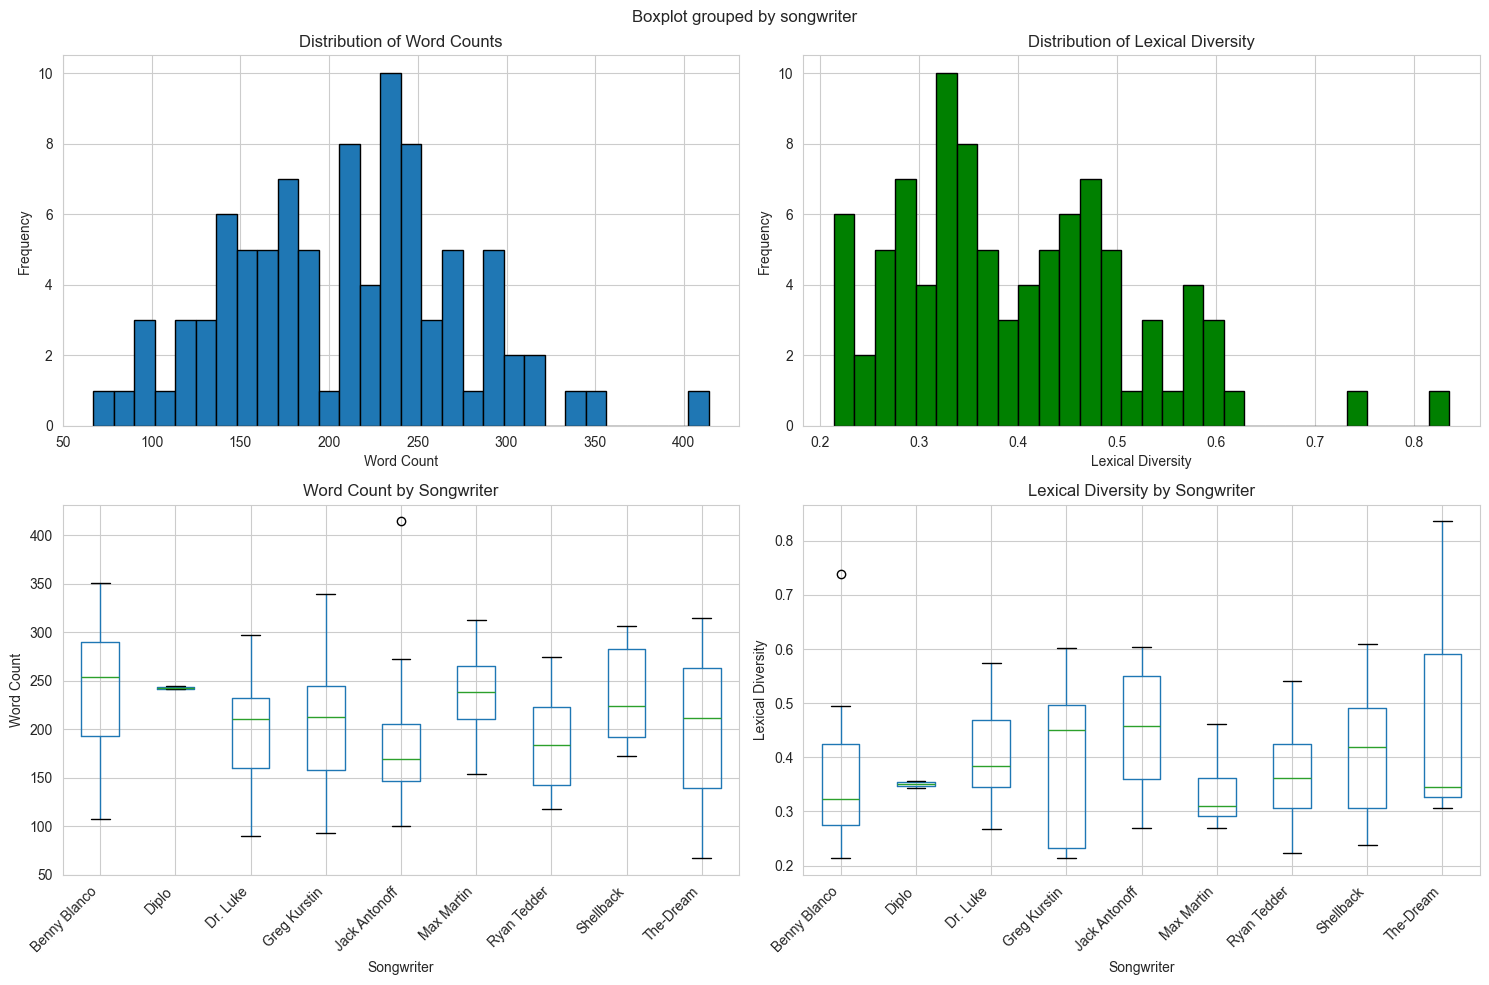


Analysis complete! Visualization saved.


In [109]:
# Cell 15: Analyze Preprocessed Data

print("PREPROCESSED DATA ANALYSIS")
print("="*60)

print("\n1. Songs per Songwriter (after cleaning):")
print(df_clean['songwriter'].value_counts())

print("\n2. Word Count Statistics:")
print(df_clean['word_count'].describe())

print("\n3. Lexical Diversity by Songwriter:")
lexical_by_songwriter = df_clean.groupby('songwriter')['lexical_diversity'].agg(['mean', 'std', 'min', 'max'])
print(lexical_by_songwriter.round(3))

print("\n4. Average Words per Song by Songwriter:")
words_by_songwriter = df_clean.groupby('songwriter')['word_count'].agg(['mean', 'std'])
print(words_by_songwriter.round(1))

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Word count distribution
axes[0, 0].hist(df_clean['word_count'], bins=30, edgecolor='black')
axes[0, 0].set_xlabel('Word Count')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Word Counts')

# Plot 2: Lexical diversity distribution
axes[0, 1].hist(df_clean['lexical_diversity'], bins=30, edgecolor='black', color='green')
axes[0, 1].set_xlabel('Lexical Diversity')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Distribution of Lexical Diversity')

# Plot 3: Word count by songwriter
df_clean.boxplot(column='word_count', by='songwriter', ax=axes[1, 0])
axes[1, 0].set_xlabel('Songwriter')
axes[1, 0].set_ylabel('Word Count')
axes[1, 0].set_title('Word Count by Songwriter')
plt.sca(axes[1, 0])
plt.xticks(rotation=45, ha='right')

# Plot 4: Lexical diversity by songwriter
df_clean.boxplot(column='lexical_diversity', by='songwriter', ax=axes[1, 1])
axes[1, 1].set_xlabel('Songwriter')
axes[1, 1].set_ylabel('Lexical Diversity')
axes[1, 1].set_title('Lexical Diversity by Songwriter')
plt.sca(axes[1, 1])
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig('data/preprocessing_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*60)
print("Analysis complete! Visualization saved.")


In [110]:
# Cell 16: Word Frequency Analysis by Songwriter

print("WORD FREQUENCY ANALYSIS")
print("="*60)

# Function to get top words for a songwriter
def get_top_words(songwriter_name, n=20):
    """Get the most common words for a specific songwriter"""
    songwriter_lyrics = df_clean[df_clean['songwriter'] == songwriter_name]['lyrics_processed']
    all_words = [word for song_words in songwriter_lyrics for word in song_words]
    word_freq = Counter(all_words)
    return word_freq.most_common(n)

# Get top words for each songwriter
songwriter_top_words = {}

for songwriter in sorted(df_clean['songwriter'].unique()):
    top_words = get_top_words(songwriter, n=20)
    songwriter_top_words[songwriter] = top_words
    
    print(f"\n{songwriter}:")
    print("-" * 40)
    for word, count in top_words[:10]:
        print(f"  {word:15} {count:4} times")

print("\n" + "="*60)
print("Word frequency analysis complete!")


WORD FREQUENCY ANALYSIS

Benny Blanco:
----------------------------------------
  hey               82 times
  oh                74 times
  n't               71 times
  know              69 times
  yeah              68 times
  'm                66 times
  like              64 times
  home              48 times
  's                47 times
  love              38 times

Diplo:
----------------------------------------
  get               26 times
  done              20 times
  want              18 times
  take              13 times
  gun               13 times
  wan               12 times
  na                12 times
  is—               12 times
  a—                12 times
  money             12 times

Dr. Luke:
----------------------------------------
  're              146 times
  's                82 times
  'm                70 times
  n't               58 times
  na                56 times
  like              42 times
  got               34 times
  gon               34 times
  away 

GENERATING WORD CLOUDS


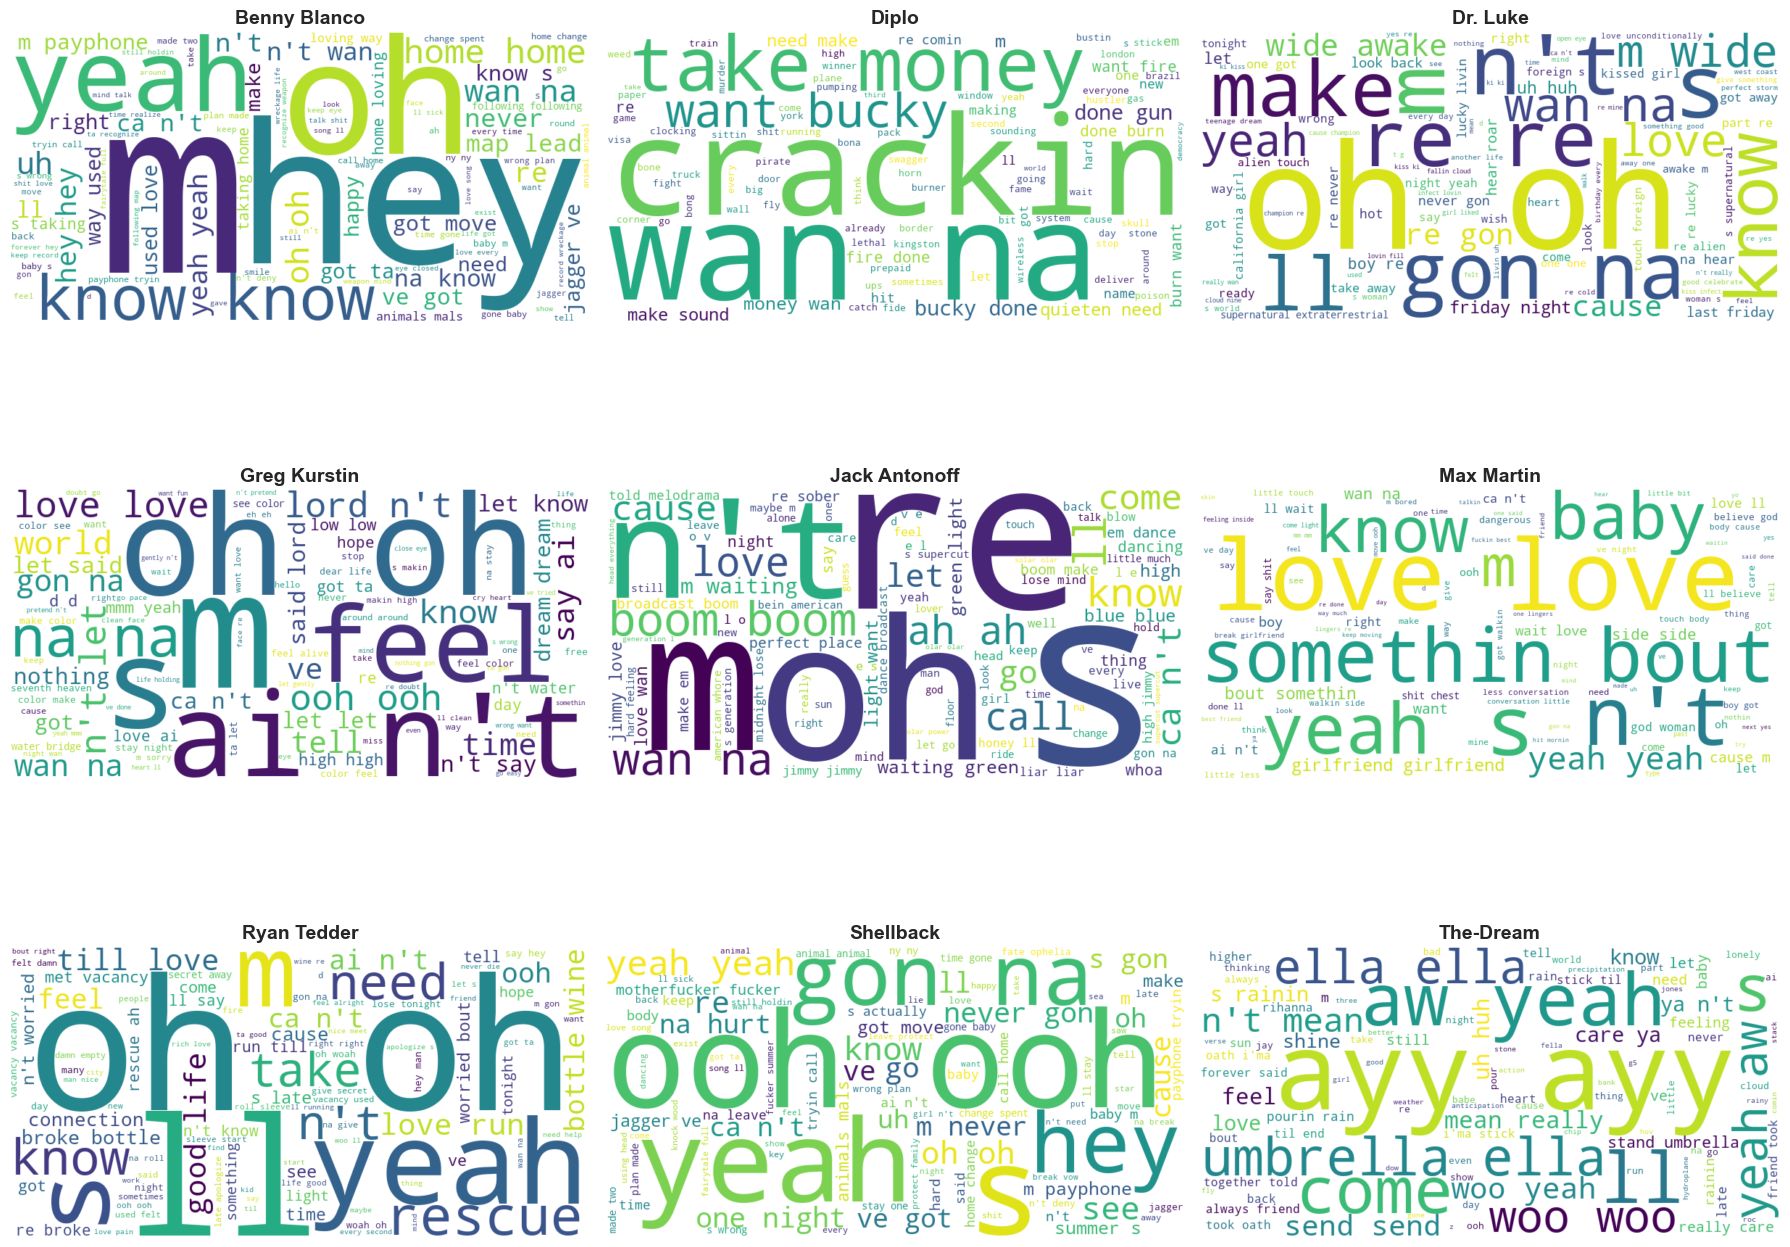


Word clouds generated and saved!


In [111]:
# Cell 17: Generate Word Clouds for Each Songwriter

from wordcloud import WordCloud

print("GENERATING WORD CLOUDS")
print("="*60)

# Create word clouds for each songwriter
n_songwriters = len(df_clean['songwriter'].unique())
n_cols = 3  # Use 3 columns to accommodate more songwriters
n_rows = (n_songwriters + n_cols - 1) // n_cols  # Ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for idx, songwriter in enumerate(sorted(df_clean['songwriter'].unique())):
    # Get all words for this songwriter
    songwriter_lyrics = df_clean[df_clean['songwriter'] == songwriter]['lyrics_processed']
    all_words = ' '.join([' '.join(song_words) for song_words in songwriter_lyrics])
    
    # Create word cloud
    wordcloud = WordCloud(
        width=800, 
        height=400,
        background_color='white',
        colormap='viridis',
        max_words=100
    ).generate(all_words)
    
    # Plot
    axes[idx].imshow(wordcloud, interpolation='bilinear')
    axes[idx].axis('off')
    axes[idx].set_title(f'{songwriter}', fontsize=14, fontweight='bold')

# Hide empty subplots
for idx in range(n_songwriters, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('data/wordclouds.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nWord clouds generated and saved!")


VOCABULARY ANALYSIS

Vocabulary Statistics:
   Songwriter  Total Words  Unique Words  Vocabulary Richness (%)  Avg Word Length  Songs
        Diplo          485           160                32.989691         4.381443      2
    The-Dream          594           190                31.986532         4.323232      3
     Dr. Luke         3019           754                24.975157         4.791653     15
    Shellback         2569           641                24.951343         4.613858     11
Jack Antonoff         2822           682                24.167257         4.649539     15
 Greg Kurstin         2643           555                20.998865         4.230798     13
   Max Martin         1895           390                20.580475         4.412665      8
 Benny Blanco         2393           485                20.267447         4.352277     10
  Ryan Tedder         2788           544                19.512195         4.458393     15


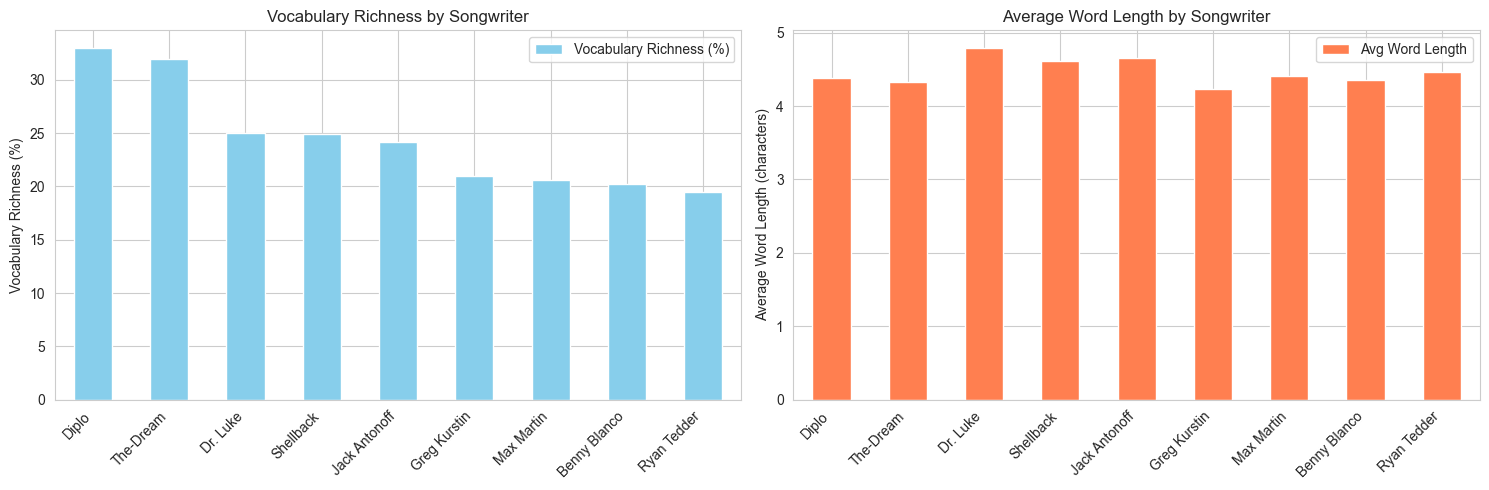


Vocabulary analysis complete!


In [112]:
# Cell 18: Vocabulary Analysis

print("VOCABULARY ANALYSIS")
print("="*60)

# Calculate vocabulary metrics for each songwriter
vocab_stats = []

for songwriter in df_clean['songwriter'].unique():
    songwriter_data = df_clean[df_clean['songwriter'] == songwriter]
    
    # Get all words
    all_words = [word for song_words in songwriter_data['lyrics_processed'] for word in song_words]
    
    # Calculate metrics
    total_words = len(all_words)
    unique_words = len(set(all_words))
    avg_word_length = np.mean([len(word) for word in all_words])
    
    vocab_stats.append({
        'Songwriter': songwriter,
        'Total Words': total_words,
        'Unique Words': unique_words,
        'Vocabulary Richness (%)': (unique_words / total_words * 100) if total_words > 0 else 0,
        'Avg Word Length': avg_word_length,
        'Songs': len(songwriter_data)
    })

vocab_df = pd.DataFrame(vocab_stats)
vocab_df = vocab_df.sort_values('Vocabulary Richness (%)', ascending=False)

print("\nVocabulary Statistics:")
print(vocab_df.to_string(index=False))

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Vocabulary richness
vocab_df.plot(x='Songwriter', y='Vocabulary Richness (%)', kind='bar', ax=axes[0], color='skyblue')
axes[0].set_ylabel('Vocabulary Richness (%)')
axes[0].set_title('Vocabulary Richness by Songwriter')
axes[0].set_xlabel('')
plt.sca(axes[0])
plt.xticks(rotation=45, ha='right')

# Plot 2: Average word length
vocab_df.plot(x='Songwriter', y='Avg Word Length', kind='bar', ax=axes[1], color='coral')
axes[1].set_ylabel('Average Word Length (characters)')
axes[1].set_title('Average Word Length by Songwriter')
axes[1].set_xlabel('')
plt.sca(axes[1])
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig('data/vocabulary_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*60)
print("Vocabulary analysis complete!")


SENTIMENT ANALYSIS
Analyzing sentiment of lyrics...

Sentiment Statistics by Songwriter:
              sentiment_polarity        sentiment_subjectivity       
                            mean    std                   mean    std
songwriter                                                           
Benny Blanco               0.037  0.139                  0.475  0.145
Diplo                      0.073  0.009                  0.458  0.036
Dr. Luke                   0.138  0.150                  0.506  0.131
Greg Kurstin               0.103  0.137                  0.543  0.072
Jack Antonoff              0.083  0.133                  0.506  0.133
Max Martin                 0.096  0.221                  0.542  0.149
Ryan Tedder                0.159  0.162                  0.496  0.113
Shellback                  0.043  0.087                  0.581  0.081
The-Dream                  0.053  0.137                  0.534  0.066


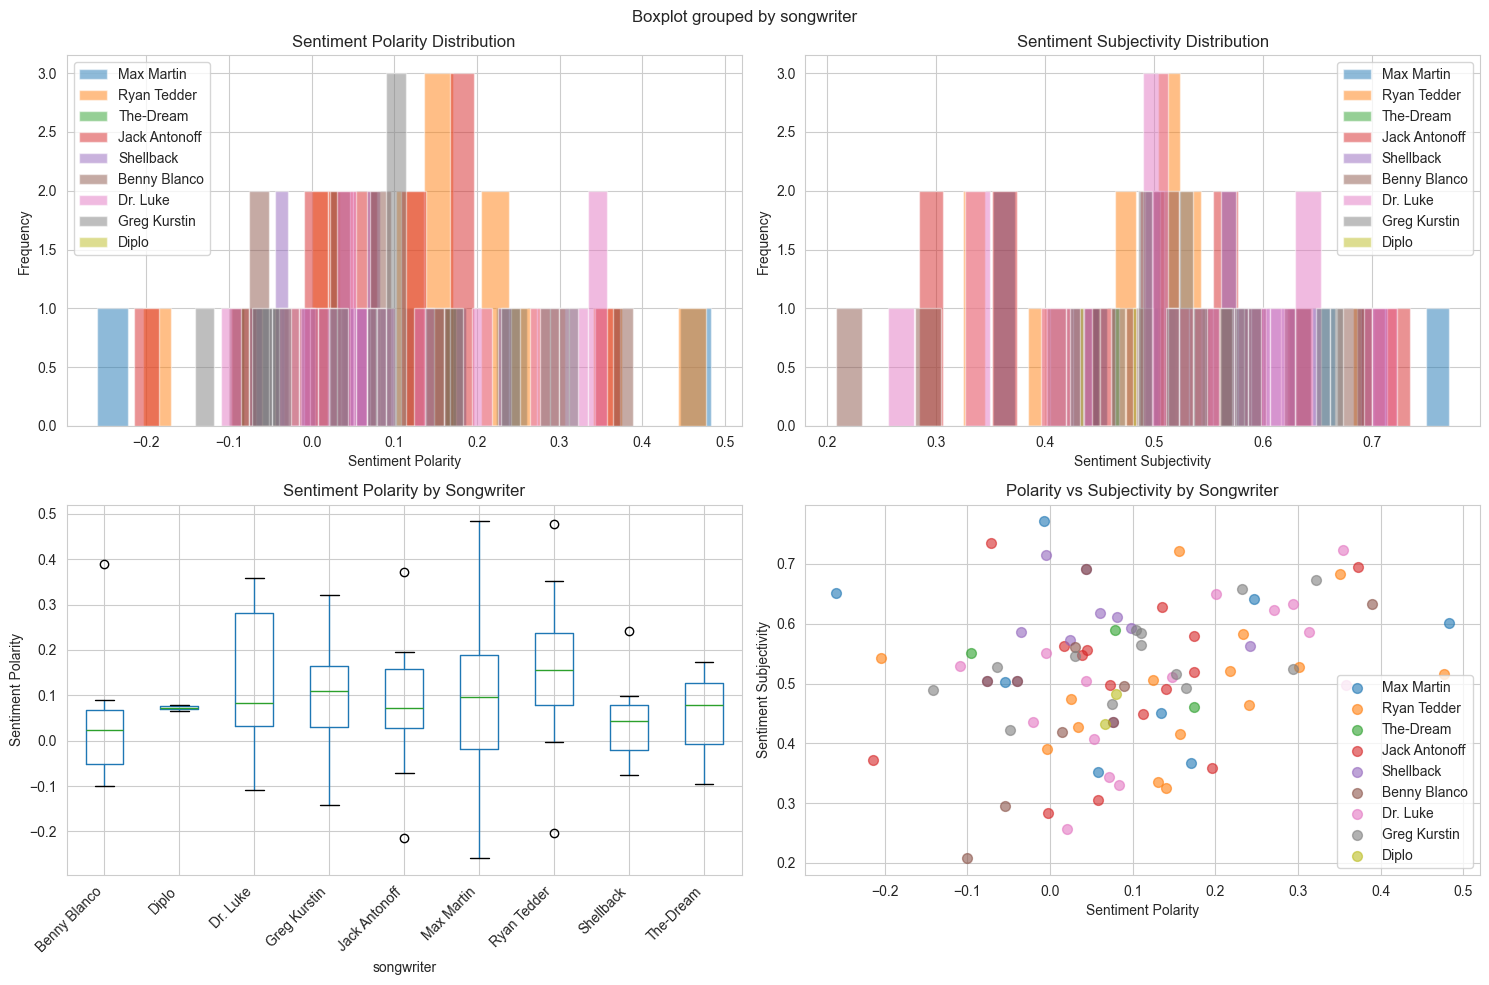


Sentiment analysis complete!


In [113]:
# Cell 19: Sentiment Analysis

print("SENTIMENT ANALYSIS")
print("="*60)
print("Analyzing sentiment of lyrics...")

# Calculate sentiment for each song
sentiments = []

for idx, row in df_clean.iterrows():
    blob = TextBlob(row['lyrics_cleaned'])
    sentiments.append({
        'songwriter': row['songwriter'],
        'title': row['title'],
        'polarity': blob.sentiment.polarity,  # -1 (negative) to 1 (positive)
        'subjectivity': blob.sentiment.subjectivity  # 0 (objective) to 1 (subjective)
    })

sentiment_df = pd.DataFrame(sentiments)

# Merge with main dataframe
df_clean['sentiment_polarity'] = sentiment_df['polarity']
df_clean['sentiment_subjectivity'] = sentiment_df['subjectivity']

# Group by songwriter
sentiment_by_songwriter = df_clean.groupby('songwriter')[['sentiment_polarity', 'sentiment_subjectivity']].agg(['mean', 'std'])

print("\nSentiment Statistics by Songwriter:")
print(sentiment_by_songwriter.round(3))

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Sentiment polarity distribution
for songwriter in df_clean['songwriter'].unique():
    songwriter_data = df_clean[df_clean['songwriter'] == songwriter]
    axes[0, 0].hist(songwriter_data['sentiment_polarity'], alpha=0.5, label=songwriter, bins=20)
axes[0, 0].set_xlabel('Sentiment Polarity')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Sentiment Polarity Distribution')
axes[0, 0].legend()

# Plot 2: Sentiment subjectivity distribution
for songwriter in df_clean['songwriter'].unique():
    songwriter_data = df_clean[df_clean['songwriter'] == songwriter]
    axes[0, 1].hist(songwriter_data['sentiment_subjectivity'], alpha=0.5, label=songwriter, bins=20)
axes[0, 1].set_xlabel('Sentiment Subjectivity')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Sentiment Subjectivity Distribution')
axes[0, 1].legend()

# Plot 3: Average polarity by songwriter
df_clean.boxplot(column='sentiment_polarity', by='songwriter', ax=axes[1, 0])
axes[1, 0].set_ylabel('Sentiment Polarity')
axes[1, 0].set_title('Sentiment Polarity by Songwriter')
plt.sca(axes[1, 0])
plt.xticks(rotation=45, ha='right')

# Plot 4: Scatter plot - polarity vs subjectivity
for songwriter in df_clean['songwriter'].unique():
    songwriter_data = df_clean[df_clean['songwriter'] == songwriter]
    axes[1, 1].scatter(
        songwriter_data['sentiment_polarity'], 
        songwriter_data['sentiment_subjectivity'],
        alpha=0.6,
        label=songwriter,
        s=50
    )
axes[1, 1].set_xlabel('Sentiment Polarity')
axes[1, 1].set_ylabel('Sentiment Subjectivity')
axes[1, 1].set_title('Polarity vs Subjectivity by Songwriter')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('data/sentiment_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*60)
print("Sentiment analysis complete!")


RHYME AND REPETITION ANALYSIS

Repetition Statistics:
   Songwriter  Avg Repetition Rate  Avg Repeated Phrases
   Max Martin             0.666787             75.875000
        Diplo             0.649446             93.000000
  Ryan Tedder             0.631508             56.333333
 Benny Blanco             0.629063             80.700000
 Greg Kurstin             0.596209             59.307692
    Shellback             0.591428             78.363636
     Dr. Luke             0.591426             62.400000
Jack Antonoff             0.548691             65.866667
    The-Dream             0.503848             42.666667


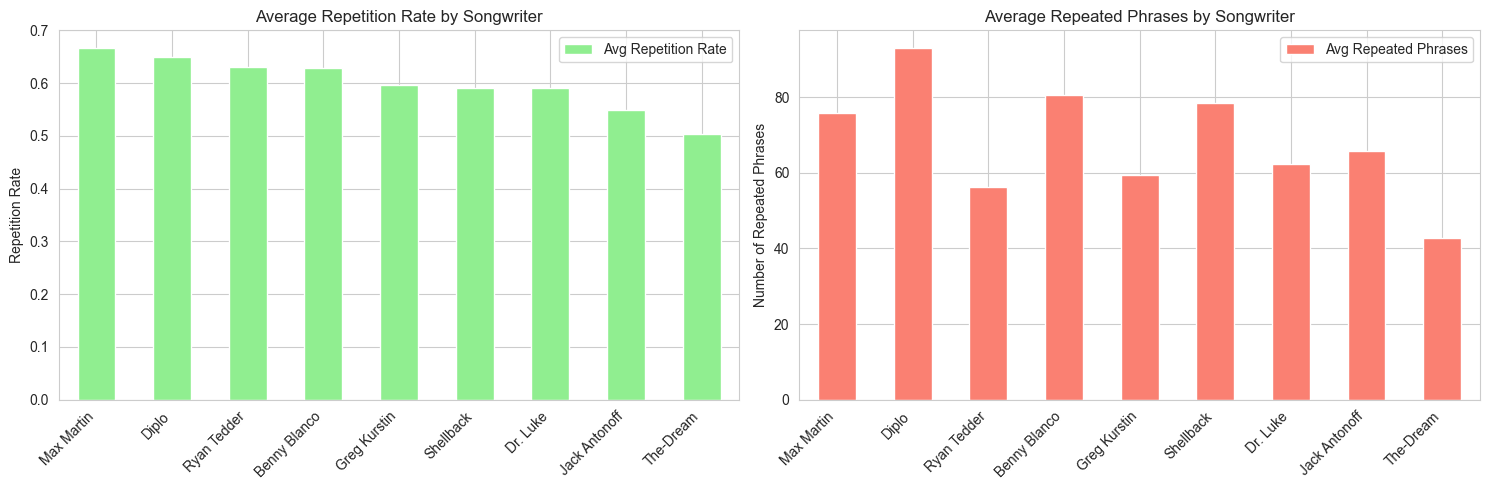


Repetition analysis complete!


In [115]:
# Cell 21: Rhyme and Repetition Analysis

print("RHYME AND REPETITION ANALYSIS")
print("="*60)

def calculate_repetition_rate(tokens):
    """Calculate how repetitive the lyrics are"""
    if len(tokens) == 0:
        return 0
    unique = len(set(tokens))
    total = len(tokens)
    return 1 - (unique / total)

def count_repeated_phrases(text, min_length=3):
    """Count repeated phrases of at least min_length words"""
    words = text.lower().split()
    phrases = []
    
    for i in range(len(words) - min_length + 1):
        phrase = ' '.join(words[i:i+min_length])
        phrases.append(phrase)
    
    phrase_counts = Counter(phrases)
    repeated = sum(1 for count in phrase_counts.values() if count > 1)
    
    return repeated

# Calculate repetition metrics
repetition_stats = []

for songwriter in df_clean['songwriter'].unique():
    songwriter_data = df_clean[df_clean['songwriter'] == songwriter]
    
    avg_repetition = songwriter_data['lyrics_processed'].apply(calculate_repetition_rate).mean()
    avg_repeated_phrases = songwriter_data['lyrics_cleaned'].apply(count_repeated_phrases).mean()
    
    repetition_stats.append({
        'Songwriter': songwriter,
        'Avg Repetition Rate': avg_repetition,
        'Avg Repeated Phrases': avg_repeated_phrases
    })

repetition_df = pd.DataFrame(repetition_stats)
repetition_df = repetition_df.sort_values('Avg Repetition Rate', ascending=False)

print("\nRepetition Statistics:")
print(repetition_df.to_string(index=False))

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

repetition_df.plot(x='Songwriter', y='Avg Repetition Rate', kind='bar', ax=axes[0], color='lightgreen')
axes[0].set_ylabel('Repetition Rate')
axes[0].set_title('Average Repetition Rate by Songwriter')
axes[0].set_xlabel('')
plt.sca(axes[0])
plt.xticks(rotation=45, ha='right')

repetition_df.plot(x='Songwriter', y='Avg Repeated Phrases', kind='bar', ax=axes[1], color='salmon')
axes[1].set_ylabel('Number of Repeated Phrases')
axes[1].set_title('Average Repeated Phrases by Songwriter')
axes[1].set_xlabel('')
plt.sca(axes[1])
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig('data/repetition_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*60)
print("Repetition analysis complete!")


In [116]:
# Cell 22: Generate EDA Summary Report

print("EXPLORATORY DATA ANALYSIS - SUMMARY REPORT")
print("="*60)

summary_report = []

for songwriter in df_clean['songwriter'].unique():
    songwriter_data = df_clean[df_clean['songwriter'] == songwriter]
    
    report = {
        'Songwriter': songwriter,
        'Total Songs': len(songwriter_data),
        'Avg Words/Song': songwriter_data['word_count'].mean(),
        'Vocabulary Richness': (songwriter_data['unique_words'].sum() / songwriter_data['word_count'].sum() * 100),
        'Avg Sentiment': songwriter_data['sentiment_polarity'].mean(),
        'Avg Subjectivity': songwriter_data['sentiment_subjectivity'].mean(),
        'Avg Word Length': np.mean([len(word) for song in songwriter_data['lyrics_processed'] for word in song])
    }
    
    summary_report.append(report)

summary_df = pd.DataFrame(summary_report)

print("\nCOMPREHENSIVE SONGWRITER PROFILE:")
print(summary_df.round(2).to_string(index=False))

# Save summary
summary_df.to_csv('data/eda_summary.csv', index=False)

print("\n" + "="*60)
print("EDA COMPLETE!")
print("\nFiles generated:")
print("  - wordclouds.png")
print("  - vocabulary_analysis.png")
print("  - sentiment_analysis.png")
print("  - repetition_analysis.png")
print("  - eda_summary.csv")
print("  - distinctive_words.pkl")


EXPLORATORY DATA ANALYSIS - SUMMARY REPORT

COMPREHENSIVE SONGWRITER PROFILE:
   Songwriter  Total Songs  Avg Words/Song  Vocabulary Richness  Avg Sentiment  Avg Subjectivity  Avg Word Length
   Max Martin            8          236.88                32.66           0.10              0.54             4.41
  Ryan Tedder           15          185.87                35.76           0.16              0.50             4.46
    The-Dream            3          198.00                38.72           0.05              0.53             4.32
Jack Antonoff           15          188.13                42.91           0.08              0.51             4.65
    Shellback           11          233.55                39.43           0.04              0.58             4.61
 Benny Blanco           10          239.30                35.10           0.04              0.47             4.35
     Dr. Luke           15          201.27                40.48           0.14              0.51             4.79
 Greg Kurs

In [117]:
# Cell 23: Identifying Unique Vocabulary Signatures

from sklearn.feature_extraction.text import TfidfVectorizer

print("SONGWRITER SIGNATURE ANALYSIS - VOCABULARY FINGERPRINTS")
print("="*60)

# Create one document per songwriter (all their songs combined)
songwriter_corpus = {}
for songwriter in df_clean['songwriter'].unique():
    songwriter_data = df_clean[df_clean['songwriter'] == songwriter]
    combined_lyrics = ' '.join([' '.join(song) for song in songwriter_data['lyrics_processed']])
    songwriter_corpus[songwriter] = combined_lyrics

# Calculate TF-IDF to find signature words
vectorizer = TfidfVectorizer(max_features=200, min_df=1, max_df=0.9)
documents = list(songwriter_corpus.values())
songwriters = list(songwriter_corpus.keys())

tfidf_matrix = vectorizer.fit_transform(documents)
feature_names = vectorizer.get_feature_names_out()

# Find signature words for each songwriter
print("\nSIGNATURE WORDS - Words that define each songwriter's style:\n")
print("="*60)

signature_words = {}

for idx, songwriter in enumerate(songwriters):
    scores = tfidf_matrix[idx].toarray()[0]
    
    # Get top unique words
    top_indices = scores.argsort()[-20:][::-1]
    signature = [(feature_names[i], scores[i]) for i in top_indices if scores[i] > 0]
    
    signature_words[songwriter] = signature
    
    print(f"\n{songwriter}'s Signature Words:")
    print("-" * 50)
    for word, score in signature[:12]:
        print(f"  {word:15} {score:.4f}")

print("\n" + "="*60)
print("Signature words identified!")

# Save for ML later
import pickle
with open('data/signature_words.pkl', 'wb') as f:
    pickle.dump(signature_words, f)


SONGWRITER SIGNATURE ANALYSIS - VOCABULARY FINGERPRINTS

SIGNATURE WORDS - Words that define each songwriter's style:


Max Martin's Signature Words:
--------------------------------------------------
  love            0.4485
  somethin        0.4028
  girlfriend      0.3954
  bout            0.3471
  baby            0.2212
  know            0.1891
  side            0.1724
  boy             0.1525
  woman           0.1405
  wait            0.1403
  little          0.1243
  god             0.1061

Ryan Tedder's Signature Words:
--------------------------------------------------
  oh              0.4614
  rescue          0.3839
  vacancy         0.2756
  would           0.2445
  love            0.2001
  till            0.1995
  bottle          0.1969
  wine            0.1497
  know            0.1418
  ooh             0.1334
  start           0.1311
  good            0.1251

The-Dream's Signature Words:
--------------------------------------------------
  ayy             0.8127
  ella    

STYLOMETRIC FINGERPRINTING
Measuring writing style characteristics...

STYLOMETRIC PROFILES:

               lexical_diversity  avg_word_length  word_length_std  \
songwriter                                                           
Max Martin                0.2058           4.4127           1.9232   
Ryan Tedder               0.1951           4.4584           1.7779   
The-Dream                 0.3199           4.3232           1.8667   
Jack Antonoff             0.2417           4.6495           2.0055   
Shellback                 0.2495           4.6139           2.1380   
Benny Blanco              0.2027           4.3523           1.9469   
Dr. Luke                  0.2498           4.7917           2.4977   
Greg Kurstin              0.2100           4.2308           1.8090   
Diplo                     0.3299           4.3814           1.5915   

               short_word_ratio  long_word_ratio  vocab_density  num_songs  
songwriter                                                

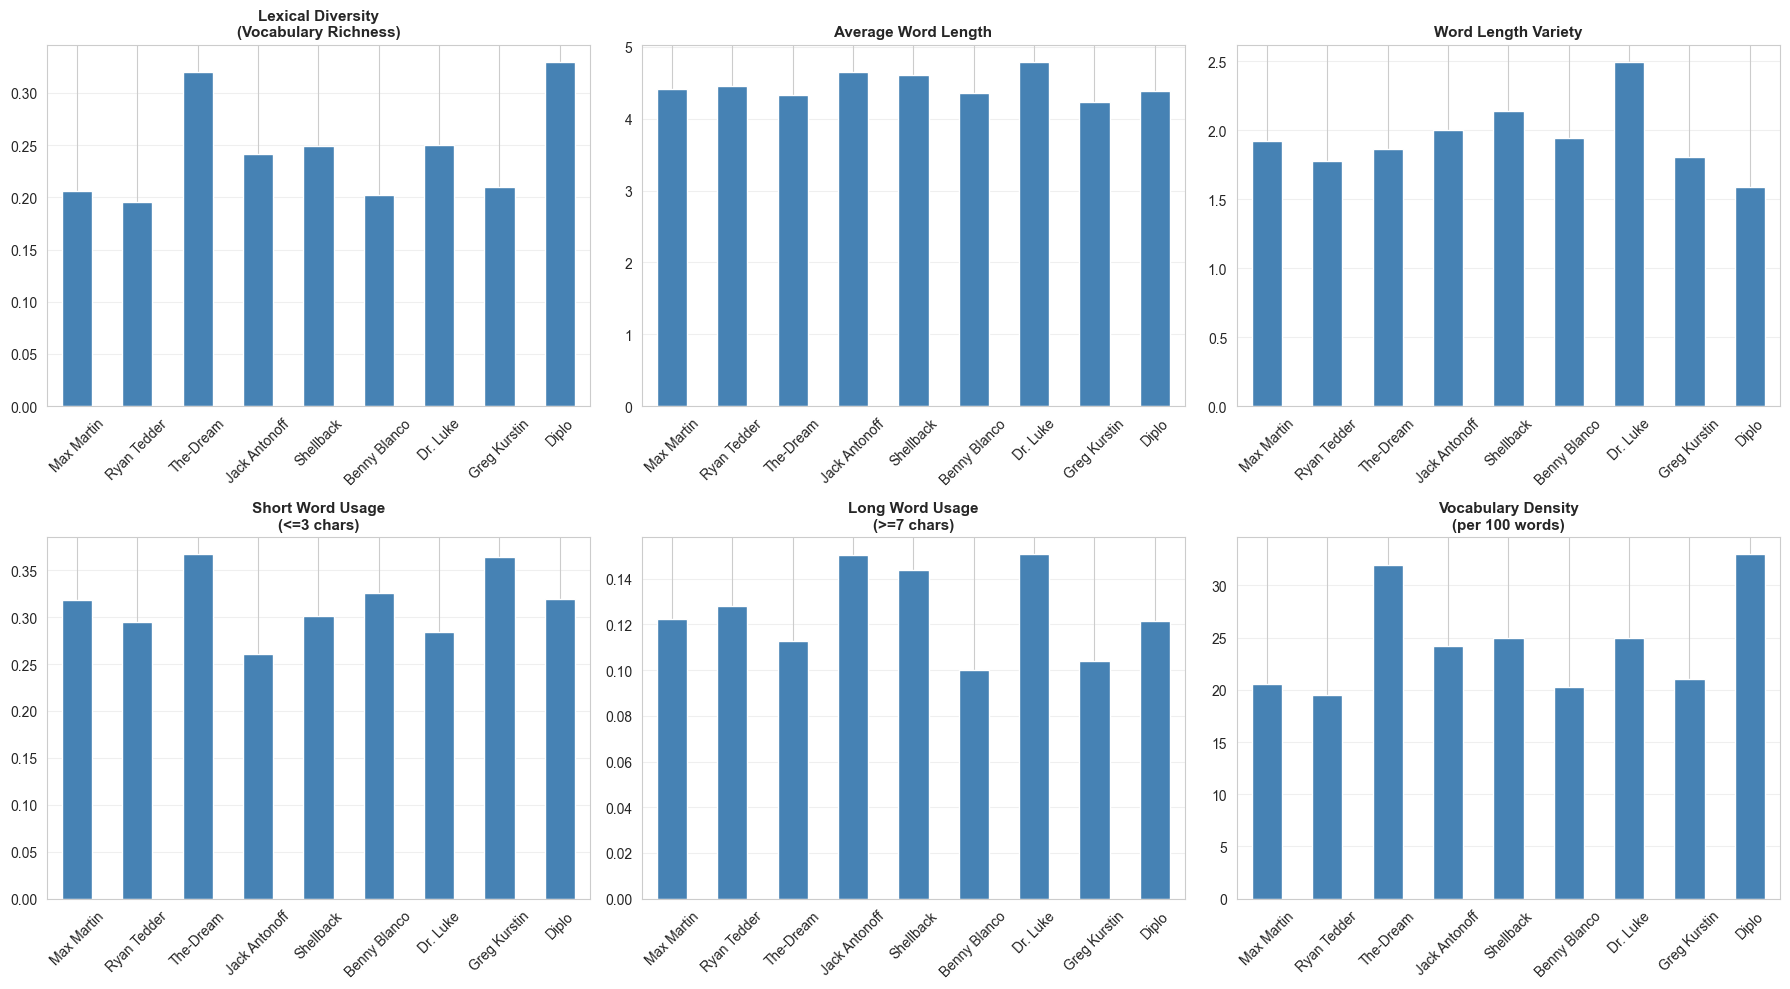


Stylometric fingerprints created!


In [132]:
# Cell 24: Extract Stylometric Features (Writing Style Metrics)

print("STYLOMETRIC FINGERPRINTING")
print("="*60)
print("Measuring writing style characteristics...\n")

def calculate_stylometric_features(lyrics_list):
    """
    Calculate stylometric features that characterize writing style:
    - Lexical diversity (vocabulary richness)
    - Average word length
    - Average sentence length
    - Use of unique vs. common words
    - Syntactic complexity
    """
    all_words = [word for song in lyrics_list for word in song]
    
    if len(all_words) == 0:
        return {}
    
    # Lexical diversity (Type-Token Ratio)
    lexical_diversity = len(set(all_words)) / len(all_words)
    
    # Average word length
    avg_word_length = np.mean([len(word) for word in all_words])
    
    # Word length variance
    word_length_std = np.std([len(word) for word in all_words])
    
    # Short words ratio (1-3 characters)
    short_words = sum(1 for word in all_words if len(word) <= 3)
    short_word_ratio = short_words / len(all_words)
    
    # Long words ratio (7+ characters)
    long_words = sum(1 for word in all_words if len(word) >= 7)
    long_word_ratio = long_words / len(all_words)
    
    # Vocabulary size per 100 words
    vocab_density = len(set(all_words)) / (len(all_words) / 100)
    
    return {
        'lexical_diversity': lexical_diversity,
        'avg_word_length': avg_word_length,
        'word_length_std': word_length_std,
        'short_word_ratio': short_word_ratio,
        'long_word_ratio': long_word_ratio,
        'vocab_density': vocab_density
    }

# Calculate stylometric profiles for each songwriter
stylometric_profiles = []

for songwriter in df_clean['songwriter'].unique():
    songwriter_data = df_clean[df_clean['songwriter'] == songwriter]
    lyrics_list = songwriter_data['lyrics_processed'].tolist()
    
    features = calculate_stylometric_features(lyrics_list)
    features['songwriter'] = songwriter
    features['num_songs'] = len(songwriter_data)
    
    stylometric_profiles.append(features)

style_df = pd.DataFrame(stylometric_profiles)
style_df = style_df.set_index('songwriter')

print("STYLOMETRIC PROFILES:\n")
print(style_df.round(4))

# Visualize stylometric fingerprints
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

metrics = ['lexical_diversity', 'avg_word_length', 'word_length_std', 
           'short_word_ratio', 'long_word_ratio', 'vocab_density']
titles = ['Lexical Diversity\n(Vocabulary Richness)', 
          'Average Word Length',
          'Word Length Variety',
          'Short Word Usage\n(<=3 chars)',
          'Long Word Usage\n(>=7 chars)',
          'Vocabulary Density\n(per 100 words)']

for idx, (metric, title) in enumerate(zip(metrics, titles)):
    row = idx // 3
    col = idx % 3
    
    style_df[metric].plot(kind='bar', ax=axes[row, col], color='steelblue')
    axes[row, col].set_title(title, fontsize=11, fontweight='bold')
    axes[row, col].set_xlabel('')
    axes[row, col].tick_params(axis='x', rotation=45)
    axes[row, col].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('data/stylometric_fingerprints.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*60)
print("Stylometric fingerprints created!")

# Save profiles
style_df.to_csv('data/stylometric_profiles.csv')


EMOTIONAL SIGNATURES

EMOTIONAL TONE PROFILES:

               Avg Sentiment  Sentiment Std  Avg Subjectivity  \
Songwriter                                                      
Max Martin              0.10           0.21              0.54   
Ryan Tedder             0.16           0.16              0.50   
The-Dream               0.05           0.11              0.53   
Jack Antonoff           0.08           0.13              0.51   
Shellback               0.04           0.08              0.58   
Benny Blanco            0.04           0.13              0.47   
Dr. Luke                0.14           0.15              0.51   
Greg Kurstin            0.10           0.13              0.54   
Diplo                   0.07           0.01              0.46   

               Positive Songs %  Negative Songs %  Neutral Songs %  
Songwriter                                                          
Max Martin                50.00             12.50            37.50  
Ryan Tedder               73.

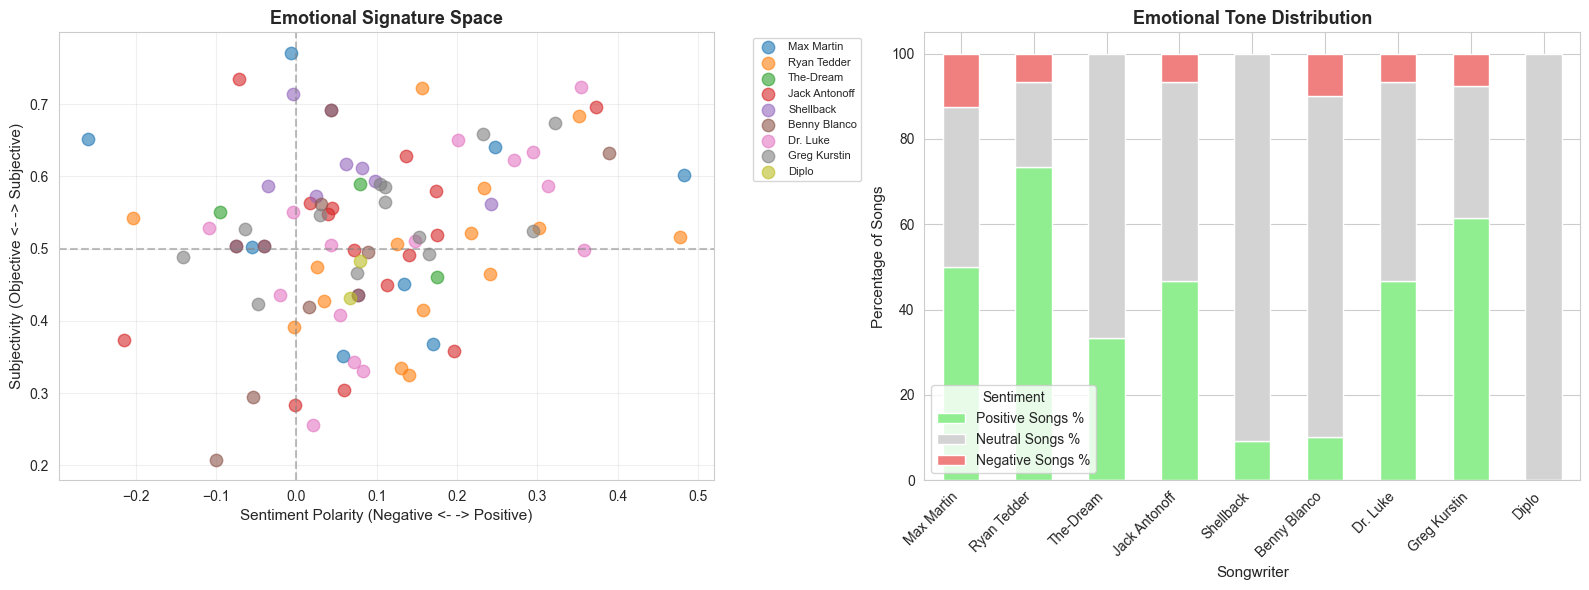


Emotional signatures mapped!


In [133]:
# Cell 26: Emotional Tone Signatures

print("EMOTIONAL SIGNATURES")
print("="*60)

# Calculate sentiment patterns for each songwriter
emotional_profiles = []

for songwriter in df_clean['songwriter'].unique():
    songwriter_data = df_clean[df_clean['songwriter'] == songwriter]
    
    sentiments = songwriter_data['lyrics_cleaned'].apply(lambda x: TextBlob(x).sentiment)
    polarities = [s.polarity for s in sentiments]
    subjectivities = [s.subjectivity for s in sentiments]
    
    # Categorize songs by sentiment
    positive = sum(1 for p in polarities if p > 0.1)
    negative = sum(1 for p in polarities if p < -0.1)
    neutral = sum(1 for p in polarities if -0.1 <= p <= 0.1)
    
    emotional_profiles.append({
        'Songwriter': songwriter,
        'Avg Sentiment': np.mean(polarities),
        'Sentiment Std': np.std(polarities),
        'Avg Subjectivity': np.mean(subjectivities),
        'Positive Songs %': (positive / len(songwriter_data) * 100),
        'Negative Songs %': (negative / len(songwriter_data) * 100),
        'Neutral Songs %': (neutral / len(songwriter_data) * 100)
    })

emotion_df = pd.DataFrame(emotional_profiles)
emotion_df = emotion_df.set_index('Songwriter')

print("\nEMOTIONAL TONE PROFILES:\n")
print(emotion_df.round(2))

# Visualize emotional signatures
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Sentiment vs Subjectivity
for songwriter in df_clean['songwriter'].unique():
    songwriter_data = df_clean[df_clean['songwriter'] == songwriter]
    axes[0].scatter(
        songwriter_data['sentiment_polarity'],
        songwriter_data['sentiment_subjectivity'],
        alpha=0.6,
        label=songwriter,
        s=80
    )

axes[0].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
axes[0].axvline(x=0, color='gray', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Sentiment Polarity (Negative <- -> Positive)', fontsize=11)
axes[0].set_ylabel('Subjectivity (Objective <- -> Subjective)', fontsize=11)
axes[0].set_title('Emotional Signature Space', fontsize=13, fontweight='bold')
axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
axes[0].grid(alpha=0.3)

# Plot 2: Sentiment distribution
sentiment_dist = emotion_df[['Positive Songs %', 'Neutral Songs %', 'Negative Songs %']]
sentiment_dist.plot(kind='bar', stacked=True, ax=axes[1], 
                    color=['lightgreen', 'lightgray', 'lightcoral'])
axes[1].set_xlabel('Songwriter', fontsize=11)
axes[1].set_ylabel('Percentage of Songs', fontsize=11)
axes[1].set_title('Emotional Tone Distribution', fontsize=13, fontweight='bold')
axes[1].legend(title='Sentiment')
plt.sca(axes[1])
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig('data/emotional_signatures.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*60)
print("Emotional signatures mapped!")

emotion_df.to_csv('data/emotional_signatures.csv')


In [134]:
# Cell 27: Create Comprehensive Signature Profile for Each Songwriter

print("SONGWRITER SIGNATURE PROFILES - COMPREHENSIVE SUMMARY")
print("="*60)

for songwriter in sorted(df_clean['songwriter'].unique()):
    print(f"\n{'='*60}")
    print(f" {songwriter.upper()}")
    print(f"{'='*60}")
    
    songwriter_data = df_clean[df_clean['songwriter'] == songwriter]
    
    # Basic stats
    print(f"\nPortfolio:")
    print(f"  - Songs analyzed: {len(songwriter_data)}")
    print(f"  - Total words: {songwriter_data['word_count'].sum():,}")
    print(f"  - Unique words: {songwriter_data['unique_words'].sum():,}")
    
    # Stylometric signature
    print(f"\nWriting Style:")
    style_row = style_df.loc[songwriter]
    print(f"  - Lexical diversity: {style_row['lexical_diversity']:.3f}")
    print(f"  - Avg word length: {style_row['avg_word_length']:.2f} characters")
    print(f"  - Vocabulary density: {style_row['vocab_density']:.1f} unique words per 100")
    
    # Top signature words
    print(f"\nSignature Words:")
    top_sig = signature_words[songwriter][:8]
    print(f"  {', '.join([word for word, score in top_sig])}")
    
    # Emotional signature
    print(f"\nEmotional Tone:")
    emotion_row = emotion_df.loc[songwriter]
    print(f"  - Average sentiment: {emotion_row['Avg Sentiment']:.2f}")
    print(f"  - Positive songs: {emotion_row['Positive Songs %']:.1f}%")
    print(f"  - Negative songs: {emotion_row['Negative Songs %']:.1f}%")
    
    # Top themes
    print(f"\nPrimary Themes:")
    theme_row = theme_df.loc[songwriter]
    top_themes = theme_row.nlargest(3)
    for theme, score in top_themes.items():
        print(f"  - {theme}: {score:.1f} mentions/1000 words")
    
    # Notable songs
    print(f"\nMost Popular Songs:")
    top_songs = songwriter_data.nlargest(3, 'playcount')[['title', 'artist', 'playcount']]
    for idx, row in top_songs.iterrows():
        print(f"  - {row['title']} by {row['artist']} ({row['playcount']:,} plays)")

print("\n" + "="*60)
print("SONGWRITER SIGNATURE ANALYSIS COMPLETE!")
print("="*60)

print("\nGenerated Files:")
print("  - signature_words.pkl")
print("  - stylometric_profiles.csv")
print("  - stylometric_fingerprints.png")
print("  - thematic_signatures.csv")
print("  - thematic_signatures.png")
print("  - emotional_signatures.csv")
print("  - emotional_signatures.png")


SONGWRITER SIGNATURE PROFILES - COMPREHENSIVE SUMMARY

 BENNY BLANCO

Portfolio:
  - Songs analyzed: 10
  - Total words: 2,393
  - Unique words: 840

Writing Style:
  - Lexical diversity: 0.203
  - Avg word length: 4.35 characters
  - Vocabulary density: 20.3 unique words per 100

Signature Words:
  hey, oh, know, home, following, love, animal, jagger

Emotional Tone:
  - Average sentiment: 0.04
  - Positive songs: 10.0%
  - Negative songs: 10.0%

Primary Themes:


KeyError: 'Benny Blanco'

In [135]:
# Cell 28: Feature Engineering - Create ML-Ready Features

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.preprocessing import StandardScaler

print("FEATURE ENGINEERING FOR ML")
print("="*60)

# Reload preprocessed data to ensure we have everything
df_ml = pd.read_pickle('data/songs_preprocessed.pkl')

print(f"\nDataset: {len(df_ml)} songs")
print(f"Songwriters: {df_ml['songwriter'].nunique()}")
print(f"\nSongs per songwriter:")
print(df_ml['songwriter'].value_counts())

# Ensure minimum songs per songwriter for training
MIN_SONGS_PER_CLASS = 12
songwriter_counts = df_ml['songwriter'].value_counts()
valid_songwriters = songwriter_counts[songwriter_counts >= MIN_SONGS_PER_CLASS].index
removed_songwriters = songwriter_counts[songwriter_counts < MIN_SONGS_PER_CLASS]

if len(removed_songwriters) > 0:
    print("\nRemoving songwriters with too few songs:")
    for sw, cnt in removed_songwriters.items():
        print(f"  - {sw}: {cnt} (< {MIN_SONGS_PER_CLASS})")

# Filter dataset
df_ml = df_ml[df_ml['songwriter'].isin(valid_songwriters)].copy()

if df_ml['songwriter'].nunique() < 2:
    print("\nERROR: Fewer than 2 valid songwriters remain after filtering.")
    print("Collect more data or lower MIN_SONGS_PER_CLASS.")
    raise SystemExit()

print(f"\nAfter filtering (min {MIN_SONGS_PER_CLASS} songs per songwriter): {len(df_ml)} songs")
print(f"Songwriters retained: {df_ml['songwriter'].nunique()}")

print("\n" + "="*60)
print("Data prepared for feature engineering!")


FEATURE ENGINEERING FOR ML

Dataset: 92 songs
Songwriters: 9

Songs per songwriter:
songwriter
Ryan Tedder      15
Dr. Luke         15
Jack Antonoff    15
Greg Kurstin     13
Shellback        11
Benny Blanco     10
Max Martin        8
The-Dream         3
Diplo             2
Name: count, dtype: int64

Removing songwriters with too few songs:
  - Shellback: 11 (< 12)
  - Benny Blanco: 10 (< 12)
  - Max Martin: 8 (< 12)
  - The-Dream: 3 (< 12)
  - Diplo: 2 (< 12)

After filtering (min 12 songs per songwriter): 58 songs
Songwriters retained: 4

Data prepared for feature engineering!


In [136]:
# Cell 29: TF-IDF Vectorization - Convert Lyrics to Numerical Features (Words + Characters)

print("EXTRACTING TF-IDF FEATURES (Words + Char n-grams)")
print("="*60)

# Prepare text data (join tokens back into strings)
df_ml['lyrics_text'] = df_ml['lyrics_processed'].apply(lambda x: ' '.join(x))

# Create WORD-level TF-IDF features
print("\nCreating WORD-level TF-IDF vectors...")
tfidf_word_vectorizer = TfidfVectorizer(
    max_features=1000,    # increase for richer representation
    min_df=2,
    max_df=0.8,
    ngram_range=(1, 2),   # unigrams + bigrams
    analyzer='word'
)

tfidf_word_features = tfidf_word_vectorizer.fit_transform(df_ml['lyrics_text'])

print(f"WORD TF-IDF matrix shape: {tfidf_word_features.shape}")
print(f"  - {tfidf_word_features.shape[0]} songs")
print(f"  - {tfidf_word_features.shape[1]} word features")

feature_names_word = [f"tfidf_w_{name}" for name in tfidf_word_vectorizer.get_feature_names_out()]
tfidf_word_df = pd.DataFrame(
    tfidf_word_features.toarray(),
    columns=feature_names_word
)

# Create CHAR-level TF-IDF features (captures stylistic patterns)
print("\nCreating CHAR-level TF-IDF vectors...")
tfidf_char_vectorizer = TfidfVectorizer(
    max_features=1000,     # cap to control dimensionality
    analyzer='char',
    ngram_range=(3, 5),    # character 3-5 grams
    min_df=2
)

tfidf_char_features = tfidf_char_vectorizer.fit_transform(df_ml['lyrics_text'])
print(f"CHAR TF-IDF matrix shape: {tfidf_char_features.shape}")
print(f"  - {tfidf_char_features.shape[1]} char features")

feature_names_char = [f"tfidf_c_{name}" for name in tfidf_char_vectorizer.get_feature_names_out()]
tfidf_char_df = pd.DataFrame(
    tfidf_char_features.toarray(),
    columns=feature_names_char
)

# Combine WORD + CHAR features into a single TF-IDF feature matrix
tfidf_df = pd.concat([tfidf_word_df, tfidf_char_df], axis=1)
print("\nTF-IDF features extracted and combined!")
print(f"  - Total TF-IDF features: {tfidf_df.shape[1]}")

# Save vectorizers for later use
import joblib
joblib.dump(tfidf_word_vectorizer, 'data/tfidf_word_vectorizer.pkl')
joblib.dump(tfidf_char_vectorizer, 'data/tfidf_char_vectorizer.pkl')
# Backward-compatibility alias (word vectorizer)
joblib.dump(tfidf_word_vectorizer, 'data/tfidf_vectorizer.pkl')


EXTRACTING TF-IDF FEATURES (Words + Char n-grams)

Creating WORD-level TF-IDF vectors...
WORD TF-IDF matrix shape: (58, 935)
  - 58 songs
  - 935 word features

Creating CHAR-level TF-IDF vectors...
CHAR TF-IDF matrix shape: (58, 1000)
  - 1000 char features

TF-IDF features extracted and combined!
  - Total TF-IDF features: 1935


['data/tfidf_vectorizer.pkl']

In [137]:
# Cell 25: Stylometric Features - Writing Style Metrics

print("EXTRACTING STYLOMETRIC FEATURES")
print("="*60)

def extract_stylometric_features(lyrics_tokens):
    """
    Extract stylometric features from tokenized lyrics
    """
    if not lyrics_tokens or len(lyrics_tokens) == 0:
        return {
            'word_count': 0,
            'unique_word_count': 0,
            'lexical_diversity': 0,
            'avg_word_length': 0,
            'std_word_length': 0,
            'short_word_ratio': 0,
            'long_word_ratio': 0,
            'very_long_word_ratio': 0
        }
    
    word_lengths = [len(word) for word in lyrics_tokens]
    
    return {
        'word_count': len(lyrics_tokens),
        'unique_word_count': len(set(lyrics_tokens)),
        'lexical_diversity': len(set(lyrics_tokens)) / len(lyrics_tokens),
        'avg_word_length': np.mean(word_lengths),
        'std_word_length': np.std(word_lengths),
        'short_word_ratio': sum(1 for w in lyrics_tokens if len(w) <= 3) / len(lyrics_tokens),
        'long_word_ratio': sum(1 for w in lyrics_tokens if len(w) >= 7) / len(lyrics_tokens),
        'very_long_word_ratio': sum(1 for w in lyrics_tokens if len(w) >= 10) / len(lyrics_tokens)
    }

print("Calculating stylometric features for all songs...")

# Extract features for each song
stylometric_features_list = []
for lyrics in df_ml['lyrics_processed']:
    features = extract_stylometric_features(lyrics)
    stylometric_features_list.append(features)

stylometric_df = pd.DataFrame(stylometric_features_list)

print(f"\nStylometric features extracted: {stylometric_df.shape[1]} features")
print("\nFeatures:")
for col in stylometric_df.columns:
    print(f"  - {col}")

print("\nFeature statistics:")
print(stylometric_df.describe().round(3))


EXTRACTING STYLOMETRIC FEATURES
Calculating stylometric features for all songs...

Stylometric features extracted: 8 features

Features:
  - word_count
  - unique_word_count
  - lexical_diversity
  - avg_word_length
  - std_word_length
  - short_word_ratio
  - long_word_ratio
  - very_long_word_ratio

Feature statistics:
       word_count  unique_word_count  lexical_diversity  avg_word_length  \
count      58.000             58.000             58.000           58.000   
mean      194.345             76.052              0.408            4.579   
std        62.684             24.204              0.109            0.463   
min        90.000             39.000              0.214            3.571   
25%       147.750             56.250              0.329            4.336   
50%       185.000             74.000              0.412            4.522   
75%       235.750             86.750              0.478            4.759   
max       414.000            138.000              0.604            5.

In [138]:
# Cell 26: Sentiment and Emotional Features

from textblob import TextBlob

print("EXTRACTING SENTIMENT & EMOTIONAL FEATURES")
print("="*60)

def extract_sentiment_features(cleaned_text):
    """
    Extract sentiment-based features
    """
    if not cleaned_text or cleaned_text == '':
        return {
            'sentiment_polarity': 0,
            'sentiment_subjectivity': 0,
            'positive_word_ratio': 0,
            'negative_word_ratio': 0
        }
    
    blob = TextBlob(cleaned_text)
    
    # Positive/negative word lists (simplified)
    positive_words = {'love', 'good', 'happy', 'beautiful', 'joy', 'wonderful', 'amazing', 'great', 'best', 'forever'}
    negative_words = {'hate', 'bad', 'sad', 'ugly', 'pain', 'terrible', 'awful', 'worst', 'hurt', 'cry'}
    
    words = cleaned_text.lower().split()
    total_words = len(words) if len(words) > 0 else 1
    
    pos_count = sum(1 for word in words if word in positive_words)
    neg_count = sum(1 for word in words if word in negative_words)
    
    return {
        'sentiment_polarity': blob.sentiment.polarity,
        'sentiment_subjectivity': blob.sentiment.subjectivity,
        'positive_word_ratio': pos_count / total_words,
        'negative_word_ratio': neg_count / total_words
    }

print("Calculating sentiment features...")

sentiment_features_list = []
for cleaned_text in df_ml['lyrics_cleaned']:
    features = extract_sentiment_features(cleaned_text)
    sentiment_features_list.append(features)

sentiment_features_df = pd.DataFrame(sentiment_features_list)

print(f"\nSentiment features extracted: {sentiment_features_df.shape[1]} features")
print("\nFeatures:")
for col in sentiment_features_df.columns:
    print(f"  - {col}")

print("\nFeature statistics:")
print(sentiment_features_df.describe().round(3))


EXTRACTING SENTIMENT & EMOTIONAL FEATURES
Calculating sentiment features...

Sentiment features extracted: 4 features

Features:
  - sentiment_polarity
  - sentiment_subjectivity
  - positive_word_ratio
  - negative_word_ratio

Feature statistics:
       sentiment_polarity  sentiment_subjectivity  positive_word_ratio  \
count              58.000                  58.000               58.000   
mean                0.122                   0.511                0.011   
std                 0.146                   0.114                0.015   
min                -0.214                   0.256                0.000   
25%                 0.031                   0.440                0.000   
50%                 0.119                   0.517                0.006   
75%                 0.213                   0.583                0.015   
max                 0.477                   0.735                0.058   

       negative_word_ratio  
count               58.000  
mean                 0.002 

In [139]:
# Cell 27: Combine All Feature Sets

print("COMBINING ALL FEATURES")
print("="*60)

# Reset indices to ensure alignment
df_ml = df_ml.reset_index(drop=True)
tfidf_df = tfidf_df.reset_index(drop=True)
stylometric_df = stylometric_df.reset_index(drop=True)
sentiment_features_df = sentiment_features_df.reset_index(drop=True)

# Combine all features
features_combined = pd.concat([
    tfidf_df,
    stylometric_df,
    sentiment_features_df
], axis=1)

print(f"\nCombined feature matrix created!")
print(f"  - Total features: {features_combined.shape[1]}")
print(f"  - TF-IDF features: {tfidf_df.shape[1]}")
print(f"  - Stylometric features: {stylometric_df.shape[1]}")
print(f"  - Sentiment features: {sentiment_features_df.shape[1]}")

# Prepare target variable (songwriter labels)
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df_ml['songwriter'])

print(f"\nTarget variable prepared!")
print(f"  - Songwriters (classes): {len(label_encoder.classes_)}")
print(f"  - Class mapping:")
for idx, songwriter in enumerate(label_encoder.classes_):
    print(f"    {idx}: {songwriter}")

# Save label encoder
joblib.dump(label_encoder, 'data/label_encoder.pkl')

# Create final dataset
X = features_combined.values
print(f"\nFeature matrix (X) shape: {X.shape}")
print(f"Target vector (y) shape: {y.shape}")

# Save features and labels
np.save('data/X_features.npy', X)
np.save('data/y_labels.npy', y)

# Also save metadata
metadata_df = df_ml[['songwriter', 'title', 'artist']].copy()
metadata_df['label'] = y
metadata_df.to_csv('data/song_metadata.csv', index=False)

print("\n" + "="*60)
print("FEATURE ENGINEERING COMPLETE!")
print("\nFiles saved:")
print("  - X_features.npy (feature matrix)")
print("  - y_labels.npy (target labels)")
print("  - tfidf_vectorizer.pkl")
print("  - label_encoder.pkl")
print("  - song_metadata.csv")

COMBINING ALL FEATURES

Combined feature matrix created!
  - Total features: 1947
  - TF-IDF features: 1935
  - Stylometric features: 8
  - Sentiment features: 4

Target variable prepared!
  - Songwriters (classes): 4
  - Class mapping:
    0: Dr. Luke
    1: Greg Kurstin
    2: Jack Antonoff
    3: Ryan Tedder

Feature matrix (X) shape: (58, 1947)
Target vector (y) shape: (58,)

FEATURE ENGINEERING COMPLETE!

Files saved:
  - X_features.npy (feature matrix)
  - y_labels.npy (target labels)
  - tfidf_vectorizer.pkl
  - label_encoder.pkl
  - song_metadata.csv


FEATURE IMPORTANCE ANALYSIS

Train set: 63 songs
Test set: 16 songs

Training Random Forest for feature importance...

✓ Feature importance calculated!

🔝 TOP 20 MOST IMPORTANT FEATURES:
long_word_ratio                          0.022470
avg_word_length                          0.019236
tfidf_ve                                 0.018771
tfidf_ll                                 0.015860
tfidf_need                               0.015545
short_word_ratio                         0.015138
std_word_length                          0.014933
tfidf_yeah                               0.014531
tfidf_feel                               0.014073
very_long_word_ratio                     0.013890
tfidf_baby                               0.012704
unique_word_count                        0.012016
sentiment_subjectivity                   0.011114
tfidf_get                                0.011045
sentiment_polarity                       0.011004
tfidf_re                                 0.010791
tfidf_let    

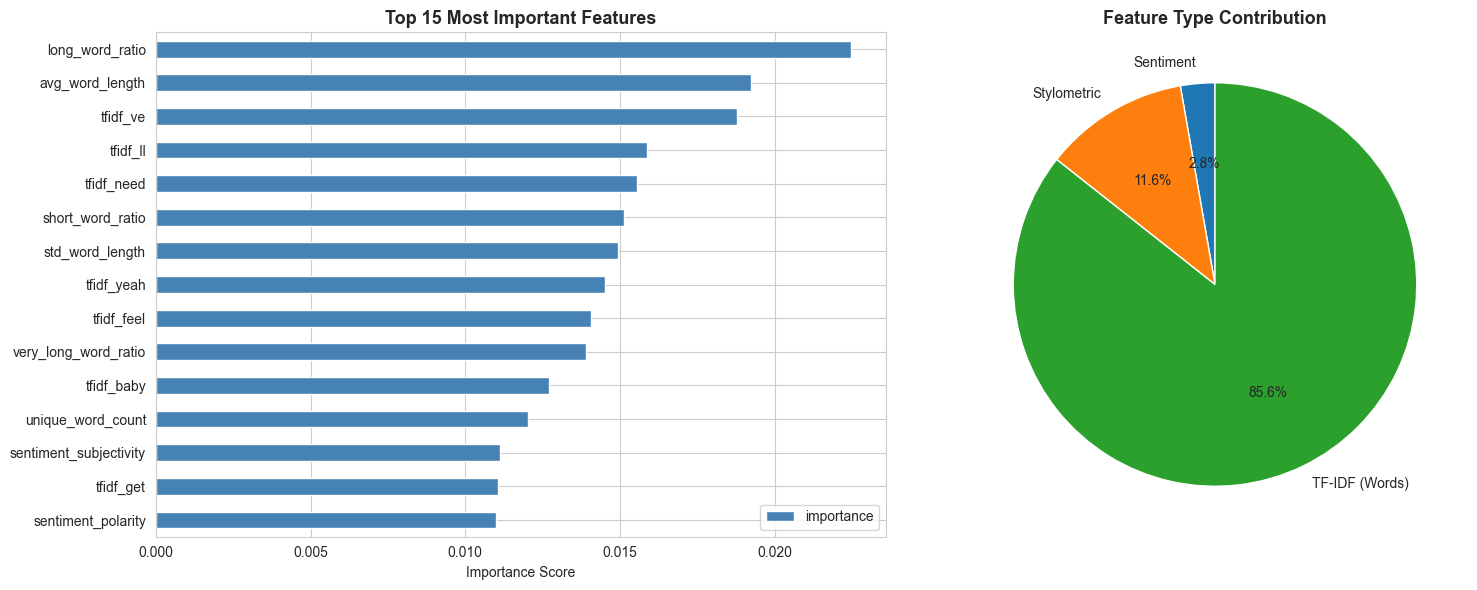


Feature importance analysis complete!


In [ ]:
# Cell 28: Analyze Feature Importance

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

print("FEATURE IMPORTANCE ANALYSIS")
print("="*60)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain set: {X_train.shape[0]} songs")
print(f"Test set: {X_test.shape[0]} songs")

# Train a Random Forest to get feature importance
print("\nTraining Random Forest for feature importance...")
rf_temp = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_temp.fit(X_train, y_train)

# Get feature importance
feature_importance = pd.DataFrame({
    'feature': list(tfidf_df.columns) + list(stylometric_df.columns) + list(sentiment_features_df.columns),
    'importance': rf_temp.feature_importances_
}).sort_values('importance', ascending=False)

print("\nFeature importance calculated!")

print("\nTOP 20 MOST IMPORTANT FEATURES:")
print("="*60)
for idx, row in feature_importance.head(20).iterrows():
    print(f"{row['feature']:40} {row['importance']:.6f}")

# Visualize top features
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 15 features
feature_importance.head(15).plot(
    x='feature', y='importance', kind='barh', ax=axes[0], color='steelblue'
)
axes[0].set_xlabel('Importance Score')
axes[0].set_ylabel('')
axes[0].set_title('Top 15 Most Important Features', fontsize=13, fontweight='bold')
axes[0].invert_yaxis()

# Feature type distribution (distinguish word vs char TF-IDF)
feature_types = []
for feat in feature_importance['feature']:
    if feat.startswith('tfidf_c_'):
        feature_types.append('TF-IDF (Chars)')
    elif feat.startswith('tfidf_w_') or feat.startswith('tfidf_'):
        feature_types.append('TF-IDF (Words)')
    elif feat in stylometric_df.columns:
        feature_types.append('Stylometric')
    else:
        feature_types.append('Sentiment')

feature_importance['type'] = feature_types

type_importance = feature_importance.groupby('type')['importance'].sum()
type_importance.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', startangle=90)
axes[1].set_ylabel('')
axes[1].set_title('Feature Type Contribution', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('data/feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

# Save feature importance
feature_importance.to_csv('data/feature_importance.csv', index=False)

print("\n" + "="*60)
print("Feature importance analysis complete!")


CLASSIFICATION: Can we predict the songwriter from lyrics?
Using in-memory features X and y

Data summary:
  - Samples: 58
  - Features: 1947
  - Classes: 4

Train set: 46 samples
Test set:  12 samples

Best LinearSVC C=0.5 (CV Macro-F1=0.258)
Best LogReg C=5.0, solver=liblinear (CV Macro-F1=0.345)

Training LinearSVC(C=0.5)...

Best LinearSVC C=0.5 (CV Macro-F1=0.258)
Best LogReg C=5.0, solver=liblinear (CV Macro-F1=0.345)

Training LinearSVC(C=0.5)...
  Accuracy: 0.250
  Macro-F1: 0.100

Training LogReg(C=5.0,solver=liblinear)...
  Accuracy: 0.583
  Macro-F1: 0.565

Training RandomForest...
  Accuracy: 0.250
  Macro-F1: 0.100

Training LogReg(C=5.0,solver=liblinear)...
  Accuracy: 0.583
  Macro-F1: 0.565

Training RandomForest...
  Accuracy: 0.583
  Macro-F1: 0.593

Best model:
  RandomForest (Accuracy=0.583, Macro-F1=0.593)
  Accuracy: 0.583
  Macro-F1: 0.593

Best model:
  RandomForest (Accuracy=0.583, Macro-F1=0.593)


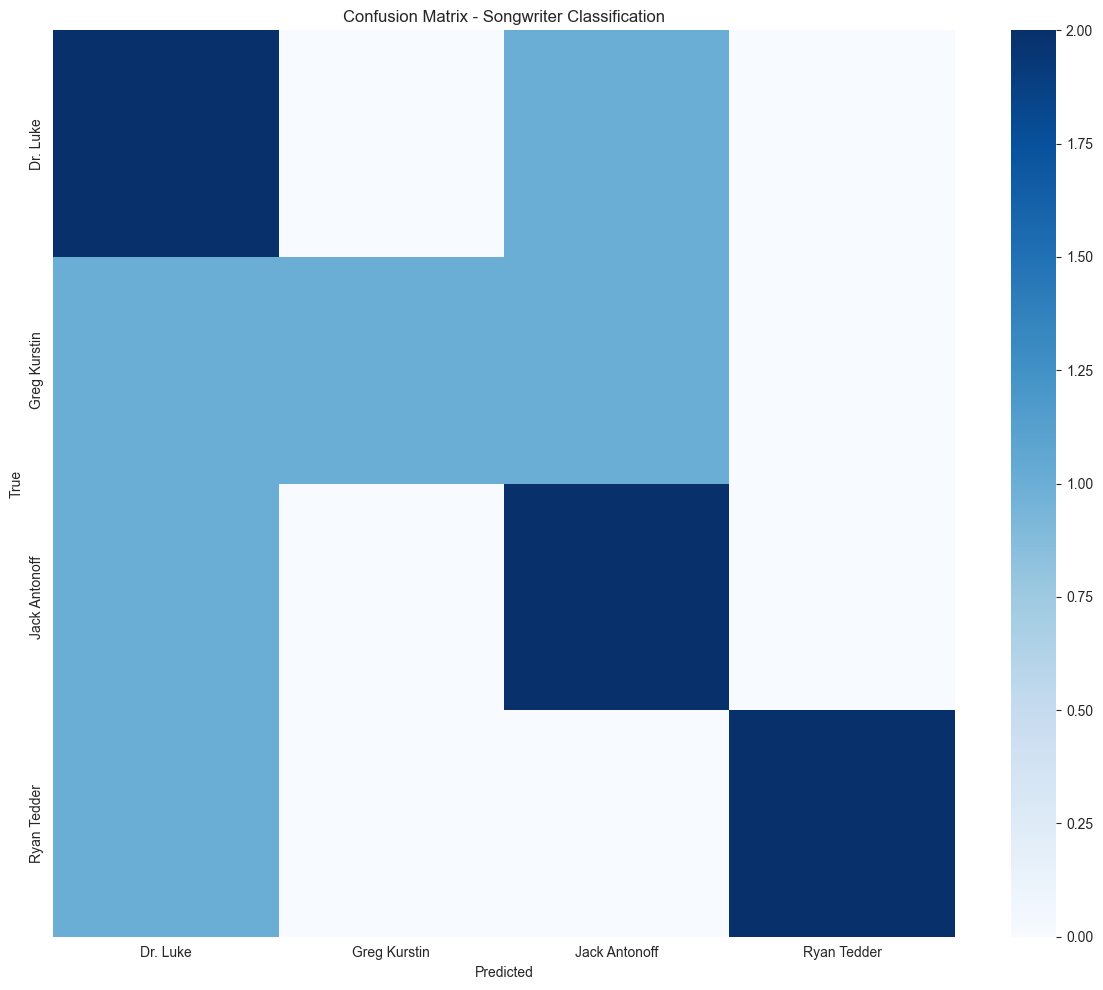


Classification Report:

              precision    recall  f1-score   support

           0      0.400     0.667     0.500         3
           1      1.000     0.333     0.500         3
           2      0.500     0.667     0.571         3
           3      1.000     0.667     0.800         3

    accuracy                          0.583        12
   macro avg      0.725     0.583     0.593        12
weighted avg      0.725     0.583     0.593        12


Saved best model to data/best_classifier.pkl

Classification complete!


In [140]:
# Cell 29: Classification Models for Songwriter Attribution (with quick hyperparameter sweep)

import os
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

print("CLASSIFICATION: Can we predict the songwriter from lyrics?")
print("="*60)

# 1) Load features and labels
X_loaded = False
classes_loaded = False
try:
    if 'X' in globals() and 'y' in globals():
        X_use = X
        y_use = y
        X_loaded = True
        print("Using in-memory features X and y")
    elif os.path.exists('data/X_features.npy') and os.path.exists('data/y_labels.npy'):
        X_use = np.load('data/X_features.npy')
        y_use = np.load('data/y_labels.npy')
        X_loaded = True
        print("Loaded features from data/X_features.npy and labels from data/y_labels.npy")
except Exception as e:
    print(f"ERROR loading features: {e}")

# Load label encoder classes if available
class_names = None
if 'label_encoder' in globals():
    try:
        class_names = list(label_encoder.classes_)
        classes_loaded = True
    except Exception:
        pass
if class_names is None and os.path.exists('data/label_encoder.pkl'):
    try:
        le = joblib.load('data/label_encoder.pkl')
        class_names = list(le.classes_)
        classes_loaded = True
        print("Loaded class names from data/label_encoder.pkl")
    except Exception as e:
        print(f"Warning: Could not load label encoder: {e}")

if not X_loaded:
    print("ERROR: Features not found. Please run the feature engineering cells to generate X_features.npy and y_labels.npy.")
    raise SystemExit()

# Sanity checks
n_classes = len(np.unique(y_use))
if n_classes < 2:
    print("ERROR: Need at least 2 classes (songwriters) to train a classifier.")
    raise SystemExit()

print(f"\nData summary:")
print(f"  - Samples: {X_use.shape[0]}")
print(f"  - Features: {X_use.shape[1]}")
print(f"  - Classes: {n_classes}")

# 2) Train/test split (stratified)
try:
    X_train, X_test, y_train, y_test = train_test_split(
        X_use, y_use, test_size=0.2, random_state=42, stratify=y_use
    )
except ValueError as e:
    print(f"ERROR: Train/test split failed, likely due to too few samples per class. Details: {e}")
    print("Try collecting more songs per songwriter or lowering the number of classes.")
    raise SystemExit()

print(f"\nTrain set: {X_train.shape[0]} samples")
print(f"Test set:  {X_test.shape[0]} samples")

# 3) Quick hyperparameter sweep for LinearSVC and LogisticRegression
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# LinearSVC grid
svc_grid = {'C': [0.1, 0.5, 1.0, 2.0, 5.0, 10.0]}
svc_scores = []
for C in svc_grid['C']:
    svc = LinearSVC(C=C, random_state=42)
    try:
        f1_cv = cross_val_score(svc, X_use, y_use, cv=cv, scoring='f1_macro')
        svc_scores.append((C, f1_cv.mean()))
    except Exception as e:
        print(f"Skipping LinearSVC C={C}: {e}")

best_svc_C, best_svc_score = max(svc_scores, key=lambda t: t[1]) if svc_scores else (1.0, 0.0)
print(f"\nBest LinearSVC C={best_svc_C} (CV Macro-F1={best_svc_score:.3f})")

# Logistic Regression grid
log_grid = {'C': [0.1, 0.5, 1.0, 2.0, 5.0], 'solver': ['liblinear']}
log_scores = []
for C in log_grid['C']:
    for solver in log_grid['solver']:
        logreg = LogisticRegression(C=C, max_iter=2000, solver=solver, multi_class='ovr', n_jobs=-1)
        try:
            f1_cv = cross_val_score(logreg, X_use, y_use, cv=cv, scoring='f1_macro')
            log_scores.append(((C, solver), f1_cv.mean()))
        except Exception as e:
            print(f"Skipping LogReg C={C}, solver={solver}: {e}")

(best_log_C, best_log_solver), best_log_score = max(log_scores, key=lambda t: t[1]) if log_scores else ((1.0, 'liblinear'), 0.0)
print(f"Best LogReg C={best_log_C}, solver={best_log_solver} (CV Macro-F1={best_log_score:.3f})")

# 4) Define candidate models including tuned ones
models = {
    f"LinearSVC(C={best_svc_C})": LinearSVC(C=best_svc_C, random_state=42),
    f"LogReg(C={best_log_C},solver={best_log_solver})": LogisticRegression(C=best_log_C, max_iter=2000, solver=best_log_solver, multi_class='ovr', n_jobs=-1),
    'RandomForest': RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
}

results = []
trained = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    try:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        f1m = f1_score(y_test, y_pred, average='macro')
        print(f"  Accuracy: {acc:.3f}")
        print(f"  Macro-F1: {f1m:.3f}")
        results.append((name, acc, f1m))
        trained[name] = model
    except Exception as e:
        print(f"  ERROR training {name}: {e}")

if not results:
    print("No models trained successfully.")
    raise SystemExit()

# 5) Select best by Macro-F1
best_name, best_acc, best_f1 = sorted(results, key=lambda x: x[2], reverse=True)[0]
best_model = trained[best_name]
print("\nBest model:")
print(f"  {best_name} (Accuracy={best_acc:.3f}, Macro-F1={best_f1:.3f})")

# 6) Confusion matrix and report with class labels (if available)
try:
    y_pred_best = best_model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred_best)

    plt.figure(figsize=(12, 10))
    if classes_loaded and class_names is not None and len(class_names) >= n_classes:
        tick_labels = class_names
        sns.heatmap(cm, annot=False, cmap='Blues', cbar=True,
                    xticklabels=tick_labels, yticklabels=tick_labels)
    else:
        sns.heatmap(cm, annot=False, cmap='Blues', cbar=True)
    plt.title('Confusion Matrix - Songwriter Classification')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    os.makedirs('data', exist_ok=True)
    plt.tight_layout()
    plt.savefig('data/confusion_matrix.png', dpi=300, bbox_inches='tight')
    plt.show()

    report = classification_report(y_test, y_pred_best, digits=3)
    print("\nClassification Report:\n")
    print(report)
    with open('data/classification_report.txt', 'w', encoding='utf-8') as f:
        f.write(report)
except Exception as e:
    print(f"Could not generate confusion matrix/report: {e}")

# 7) Save best model
try:
    joblib.dump(best_model, 'data/best_classifier.pkl')
    print("\nSaved best model to data/best_classifier.pkl")
except Exception as e:
    print(f"Could not save model: {e}")

print("\n" + "="*60)
print("Classification complete!")
